# Can Odysse cut the 61% of offers that go unaccepted by sending each trip to the driver most likely to take it, without giving anyone more work?

When a rider books, Odysse offers the trip to a driver. In six days (17–22 Aug), 61% of 5,576 offers went unaccepted: 43% got no response and 18% were turned down. Each one costs the rider time and leaves a salaried driver's shift under-used.

This isn't about good and bad drivers. Drivers differ in when they're available and what they prefer, and dispatch currently treats them as interchangeable. Four questions:

1. **Is it the trips?** Where and when requests come from explains under 1% of the differences here; at most a few per cent under every alternative tested offline. **No: which driver gets the offer matters.**
2. **Does each driver have a consistent working pattern?** Three days predict the other three (r ≈ 0.83; ≈ 0.84 allowing for the offers). **Yes: it can be learned.**
3. **Do drivers prefer different trips?** Some consistently prefer short trips, others long ones (r ≈ 0.77, p ≈ 0.001); fleet-wide averages hide this: the preferences cancel out. **Yes: "most likely to take it" depends on the trip.**
4. **Could dispatch use this?** A prototype router picks from nearby drivers on two unseen days. The offers it would move were accepted less often by their assigned driver (32% vs 44%). **Possibly: it needs a live test.**

**So what:** re-route sooner after a run of no-responses; build a preference profile drivers can see and adjust; A/B test preference-aware dispatch at equal workload.

A prototype router shows the mechanism but cannot size it: against routers rebuilt on scrambled driver histories, only about +0.2 points of its offline gain survives. The case for acting rests on the held-out test in step 4; an A/B test at equal workload is what would measure the size.

## How to reproduce

- **Environment:** Python 3.11 or newer with pandas, numpy, scipy, matplotlib and scikit-learn (listed in `requirements.txt`).
- **Run:** create a venv, `pip install -r requirements.txt`, then Run All (or `python run_notebook.py`).
  About 30 seconds warm (28 s measured), a minute the first time; the step 3 permutation test is the largest
  single piece, about a third of it. It reads only the workbook in `data/raw/`.
- **Randomness:** every random step starts from the one `SEED` in the first code cell, so reruns match.
- **Where the headline numbers are computed:** 61% not accepted: Step 0 (cell 6); the 8–84% spread (cell 10).
  55–64% expected and the request-mix share: Step 1 (cell 17). r = 0.83 and 0.84: Step 2 (cell 22).
  r = 0.77 and its p: Step 3 (cell 31). Held-out gains: Step 4 (cell 44); the mileage lead (cell 52).
  Router table and the 32% vs 44%: Step 5 (cells 61–62). Fares: Step 6 (cell 67); where the capacity
  is (cell 69). The check cells (73–76) re-assert them all.

## Step 0. What counts as unaccepted, and how distance is measured — deck slide 2

*Backs deck slide 2 ("Six offers in ten go unaccepted").*

- **Row** = one offer to one driver; 19 August is nearly empty.
- **Not accepted** = no response (43%) or turned down (18%). **Accepted** = an acceptance time is recorded (37%).
- **Driver comparisons** use the 35 drivers with ≥ 50 offers (97.5% of offers). **Two sets of days** (17, 19, 21 and 18, 20,
  22 August) check that patterns repeat.
- **Distance is straight-line km (from pickup and dropoff coordinates)**: trip length (long = ≥ 8) and rings around Charing
  Cross (Central < 3, Inner 3–8, Outer 8–15, Far 15+). `distance_in_miles` is the platform's recorded trip distance and is 0
  for unfinished offers, so straight-line distance is used for all offers. On finished trips the two correlate 0.955, and
  road distance is about 1.4× straight-line.
- **Airport** is a product label, not a zone.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from matplotlib.ticker import FuncFormatter, PercentFormatter
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import KFold, cross_val_score

SEED = 42           # one seed for every random step, so reruns match
MIN_OFFERS = 50     # a driver needs this many offers before being compared with other drivers
MIN_CELL = 20       # a rate needs this many offers before it is worth quoting

ACCENT, GREY, LIGHT = '#1f6f8b', '#8c8c8c', '#e6e6e6'      # one palette for every chart
GREEN, BLUE_GREY, ORANGE = '#3a9d6b', '#9fb3c8', '#e08a3c'

pd.set_option('display.width', 200, 'display.float_format', '{:.2f}'.format)
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
                     'axes.labelsize': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlelocation': 'left',
                     'figure.dpi': 66})    # tools/export_charts.py renders at 200 dpi

In [2]:
# Chart conventions shared by every step, so the charts all read the same way.

def titled(ax, title, subtitle):
    '''Bold finding as the chart title, with the method in a smaller grey line underneath.
    Used by every chart so they all read the same way on a projector.'''
    ax.set_title(title, pad=26)
    note = ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10, color=GREY, va='bottom')
    note.set_in_layout(False)      # the subtitle sits outside the axes, so ignore it when packing

def pct(ax, axis='x'):
    '''Label one axis as whole percentages, for the many charts whose values are shares from 0 to 1.
    Pass axis='y' for the vertical axis.'''
    (ax.xaxis if axis == 'x' else ax.yaxis).set_major_formatter(PercentFormatter(1.0, decimals=0))

def signed_points(value, position):
    '''Tick label for an axis of differences in percentage points: +20, 0, -20.
    Uses a true minus sign so the ticks match the surrounding prose.'''
    return '0' if value == 0 else f'{value:+.0f}'.replace('-', '−')

signed = FuncFormatter(signed_points)

In [3]:
def km_between(lat1, lon1, lat2, lon2):
    '''Straight-line (great-circle) distance in km between two points given in degrees.
    Used for the rings around Charing Cross and for trip length; the platform's recorded distance
    exists only for finished trips.'''
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    half_chord = (np.sin((lat2 - lat1) / 2) ** 2
                  + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * 6371.0088 * np.arcsin(np.sqrt(half_chord))

In [4]:
# The workbook lives in data/raw/ (from here or one level up), or next to the notebook.
WORKBOOK = 'interview-take-home-dataset.xlsx'
candidate_paths = [Path('data/raw') / WORKBOOK, Path('../data/raw') / WORKBOOK, Path(WORKBOOK)]
data_file = next(path for path in candidate_paths if path.exists())
offers = pd.read_excel(data_file, sheet_name='Trips')

# One row = one offer to one driver. Sorting now makes every later "the driver's previous
# offer" step mean what it says.
offers = offers.sort_values(['driver_id', 'dispatched_datetime'], kind='stable')
offers = offers.reset_index(drop=True)

# The two ways an offer falls through, and the one way it succeeds.
offers['turned_down'] = offers.status.eq('Driver rejected').astype(int)
offers['no_response'] = offers.status.eq('Driver did not respond').astype(int)
offers['not_accepted'] = offers.turned_down + offers.no_response
offers['accepted'] = offers.order_accepted_timestamp.notna().astype(int)

print(f'{len(offers):,} offers, {offers.driver_id.nunique()} drivers | '
      f'not accepted {offers.not_accepted.sum():,} = {offers.not_accepted.mean():.1%} '
      f'(turned down {offers.turned_down.mean():.1%}, '
      f'no response {offers.no_response.mean():.1%}) '
      f'| accepted {offers.accepted.mean():.1%}')

5,576 offers, 42 drivers | not accepted 3,394 = 60.9% (turned down 18.4%, no response 42.5%) | accepted 36.9%


In [5]:
CENTRE = (51.5074, -0.1278)          # Charing Cross (latitude, longitude)

# The workbook stores each coordinate as one "lat,long" string, so split it into two numbers.
pickup = offers.pickup_lat_long.str.split(',', expand=True).astype(float)
dropoff = offers.dropoff_latlong.str.split(',', expand=True).astype(float)
pickup_lat, pickup_lon = pickup[0], pickup[1]
dropoff_lat, dropoff_lon = dropoff[0], dropoff[1]

# How far the pickup is from the centre, and how far the trip itself runs.
km_from_centre = km_between(pickup_lat, pickup_lon, *CENTRE)
offers['trip_km'] = km_between(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon)
offers['long_trip'] = offers.trip_km >= 8
offers['log_km'] = np.log1p(offers.trip_km)

# Four rings around the centre, by that distance in km.
ring_edges = [0, 3, 8, 15, np.inf]
ring_names = ['Central', 'Inner', 'Outer', 'Far']
pickup_ring = pd.cut(km_from_centre, ring_edges, right=False, labels=ring_names)
offers['pickup_ring'] = pickup_ring.astype(str)

# Pickup position as flat km east and north of the centre, for the map and the 2 km squares.
offers['x_km'] = (pickup_lon - CENTRE[1]) * np.cos(np.radians(CENTRE[0])) * 111.32
offers['y_km'] = (pickup_lat - CENTRE[0]) * 110.574

In [6]:
# Time of day on two grids: six-hour blocks for the step 1 benchmark, three-hour bins for models.
dispatch_hour = offers.dispatched_datetime.dt.hour
block_edges = [0, 6, 12, 18, 24]
block_names = ['00–06', '06–12', '12–18', '18–24']
time_block = pd.cut(dispatch_hour, block_edges, right=False, labels=block_names)
offers['time_block'] = time_block.astype(str)
offers['hour_bin'] = (dispatch_hour // 3).astype(str)

# The calendar day, and two sets of alternating days used to check that patterns repeat.
offers['day'] = offers.dispatched_datetime.dt.day
offers['day_set'] = 'B'
offers.loc[offers.day.isin([17, 19, 21]), 'day_set'] = 'A'

# The product name without its trailing "[...]" tag.
product = offers.category.str.replace(r'\s*\[.*$', '', regex=True)
offers['product'] = product.str.strip()

print('offers per day:', offers.groupby('day').size().to_dict(),
      '| drivers on 19 Aug:', offers[offers.day == 19].driver_id.nunique())

offers per day: {17: 1171, 18: 924, 19: 126, 20: 983, 21: 1041, 22: 1331} | drivers on 19 Aug: 7


In [7]:
# The platform records its own trip distance, but only once a trip has finished.
finished = offers[offers.distance_in_miles > 0]
straight_vs_recorded = finished.trip_km.corr(finished.distance_in_miles)

# How much longer the road is than the straight line. Very short trips are dropped because
# their ratio is dominated by rounding.
long_enough = finished[finished.trip_km > 0.5]
road_km = long_enough.distance_in_miles * 1.609
road_ratio = (road_km / long_enough.trip_km).median()

print(f'finished trips: straight-line vs recorded distance r = {straight_vs_recorded:.3f}; '
      f'road ÷ straight-line, median {road_ratio:.2f}×')

finished trips: straight-line vs recorded distance r = 0.955; road ÷ straight-line, median 1.41×


In [8]:
# One row per driver: how many offers they were sent, and how they answered.
by_driver_id = offers.groupby('driver_id')
drivers = by_driver_id.agg(offers=('not_accepted', 'size'),
                           not_accepted_rate=('not_accepted', 'mean'),
                           no_response=('no_response', 'mean'),
                           turned_down=('turned_down', 'mean'))

# A driver with only a handful of offers cannot be told apart from noise, so comparisons
# throughout use only the drivers above MIN_OFFERS.
main = drivers[drivers.offers >= MIN_OFFERS]
main = main.sort_values('not_accepted_rate')

# Each driver's own share not accepted, copied beside every one of their offers. Step 2 uses it.
offers['usual_rate'] = offers.driver_id.map(drivers.not_accepted_rate)
offers['vs_usual'] = offers.not_accepted - offers.usual_rate

# How far apart these drivers would look if nothing but sampling noise separated them: the
# standard error of a share, averaged over the drivers.
noise_variance = main.not_accepted_rate * (1 - main.not_accepted_rate) / main.offers
chance_sd = np.sqrt(noise_variance.mean())

print(f'{len(main)} drivers with ≥{MIN_OFFERS} offers = {main.offers.sum() / len(offers):.1%} '
      f'of offers ({main.offers.min()}–{main.offers.max()} offers each)')
print(f'share not accepted: {main.not_accepted_rate.min():.1%} to '
      f'{main.not_accepted_rate.max():.1%}, sd {main.not_accepted_rate.std():.3f} '
      f'| sd expected from chance alone: {chance_sd:.3f}')

35 drivers with ≥50 offers = 97.5% of offers (69–447 offers each)
share not accepted: 8.5% to 84.1%, sd 0.192 | sd expected from chance alone: 0.042


In [9]:
# Of a driver's not-accepted offers, what share was silence and what share was a refusal?
# Dividing each rate by the driver's overall not-accepted rate turns them into shares of the misses.
kind_share = pd.DataFrame(index=main.index)
kind_share['no_response'] = main.no_response / main.not_accepted_rate
kind_share['turned_down'] = main.turned_down / main.not_accepted_rate

# A driver answers "almost entirely one way" if either share is 90% or more.
one_kind = kind_share >= .9
drivers_one_kind = one_kind.any(axis=1).sum()

print(f'drivers whose not-accepted offers are ≥90% one kind: {drivers_one_kind} '
      f'(no response: {one_kind.no_response.sum()}, turned down: {one_kind.turned_down.sum()})')

drivers whose not-accepted offers are ≥90% one kind: 21 (no response: 16, turned down: 5)


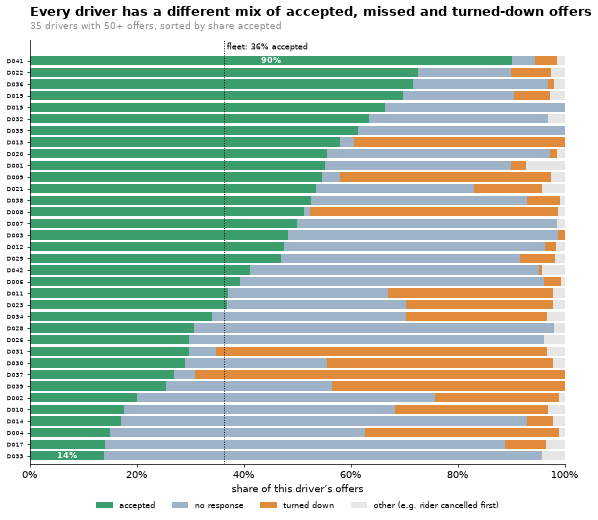

In [10]:
# The mix of outcomes, one stacked bar per driver.
main_offers = offers[offers.driver_id.isin(main.index)]      # offers the 35 compared drivers got
outcome_columns = ['accepted', 'no_response', 'turned_down']
shares = main_offers.groupby('driver_id')[outcome_columns].mean()
shares['other'] = (1 - shares.sum(axis=1)).clip(lower=0)     # e.g. the rider cancelled first
shares = shares.sort_values('accepted')
fleet_accepted = main_offers.accepted.mean()
layers = [('accepted', GREEN, 'accepted'),
          ('no_response', BLUE_GREY, 'no response'),
          ('turned_down', ORANGE, 'turned down'),
          ('other', LIGHT, 'other (e.g. rider cancelled first)')]
rows, left = np.arange(len(shares)), np.zeros(len(shares))

fig, ax = plt.subplots(figsize=(9, 8))
for column, colour, label in layers:
    ax.barh(rows, shares[column], left=left, color=colour, height=.8, label=label)
    left = left + shares[column].to_numpy()
ax.axvline(fleet_accepted, color='k', linestyle=':', lw=1)
ax.text(fleet_accepted, len(shares) - .2, f' fleet: {fleet_accepted:.0%} accepted',
        fontsize=9, va='bottom')
for row in (0, len(shares) - 1):                             # label the bottom and the top bar
    ax.text(shares.accepted.iloc[row] / 2, row, f'{shares.accepted.iloc[row]:.0%}',
            color='white', fontsize=9, ha='center', va='center', weight='bold')
ax.set_yticks(rows, shares.index.str.replace('Driver_', 'D'), fontsize=7)
ax.set(xlim=(0, 1), ylim=(-.7, len(shares) + .8)); pct(ax)
ax.set_xlabel('share of this driver’s offers')
ax.legend(ncol=4, fontsize=9, loc='upper center', bbox_to_anchor=(.5, -.07), frameon=False)
titled(ax, 'Every driver has a different mix of accepted, missed and turned-down offers',
       f'{len(shares)} drivers with 50+ offers, sorted by share accepted')
plt.tight_layout(); plt.show()

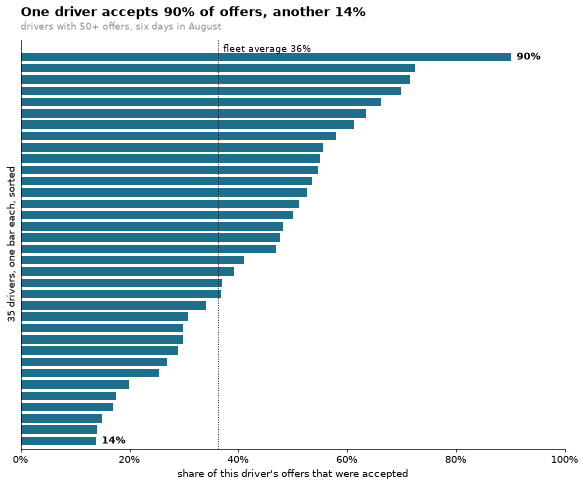

In [11]:
# Deck slide 2 uses this plainer version: one number per driver, share accepted.
accepted_share = shares.accepted
rows = np.arange(len(accepted_share))
fig, ax = plt.subplots(figsize=(9, 7.5))
ax.barh(rows, accepted_share, color=ACCENT, height=.75)
ax.axvline(fleet_accepted, color='k', linestyle=':', lw=1)
ax.text(fleet_accepted + .01, len(accepted_share) - .3,
        f'fleet average {fleet_accepted:.0%}', fontsize=10, va='center')
for row in (0, len(accepted_share) - 1):                     # label the lowest and the highest bar
    ax.text(accepted_share.iloc[row] + .01, row, f'{accepted_share.iloc[row]:.0%}',
            va='center', fontsize=11, weight='bold')
ax.set(xlim=(0, 1), ylim=(-.7, len(accepted_share) + .5), yticks=[],
       xlabel="share of this driver's offers that were accepted",
       ylabel=f'{len(accepted_share)} drivers, one bar each, sorted'); pct(ax)
headline = (f'One driver accepts {accepted_share.max():.0%} of offers, '
            f'another {accepted_share.min():.0%}')
titled(ax, headline, 'drivers with 50+ offers, six days in August')
plt.tight_layout(); plt.show()

**Drivers respond very differently, and in different ways.** The share not accepted runs from **8% to 84%**; chance alone
would spread these drivers by about 4 points, and the actual spread is 19. 21 of the 35 respond almost entirely one way: 16
mostly by not responding, 5 mostly by turning offers down. These are response patterns, not a ranking of people.

## Step 1. Is it the trips? — deck slide 3

*Backs deck slide 3 ("Is it the trips?").*

If drivers accept less because of the work they are given, then what *other* drivers do with the same kind of offer should
predict each driver's rate.

In [12]:
def expected_from_others(cell_columns, outcome):
    '''For each offer, how often OTHER drivers' offers in the same cell had this outcome.
    A "cell" is a group of similar offers, such as pickup ring × time block. The driver's own
    offers are taken out of the benchmark, so nobody is ever measured against themselves.'''
    # For the whole cell: how many offers it holds, and how many of them had the outcome.
    by_cell = offers.groupby(cell_columns)[outcome]
    cell_totals = by_cell.agg(cell_outcomes='sum', cell_offers='count')

    # The same two counts again, but for one driver's offers inside that cell.
    by_cell_and_driver = offers.groupby(cell_columns + ['driver_id'])[outcome]
    own_totals = by_cell_and_driver.agg(own_outcomes='sum', own_offers='count')

    # Put both sets of counts beside every offer.
    beside = offers[cell_columns + ['driver_id']].join(cell_totals, on=cell_columns)
    beside = beside.join(own_totals, on=cell_columns + ['driver_id'])

    # Leave the driver out: take their own counts off the cell's, then divide.
    others_outcomes = beside.cell_outcomes - beside.own_outcomes
    others_offers = beside.cell_offers - beside.own_offers
    expected = others_outcomes / others_offers

    # A cell holding too few other-driver offers cannot give a usable rate.
    expected[others_offers < MIN_CELL] = np.nan
    return expected

In [13]:
# The benchmark for each offer: pickup ring × time block where that cell is big enough, and the
# pickup ring on its own where it is not. turned_down and no_response are reused in step 3.
for outcome in ['not_accepted', 'turned_down', 'no_response']:
    by_ring_and_block = expected_from_others(['pickup_ring', 'time_block'], outcome)
    by_ring_only = expected_from_others(['pickup_ring'], outcome)
    offers[f'expected_{outcome}'] = by_ring_and_block.fillna(by_ring_only)

In [14]:
# One row per compared driver: their own rate, and what their offers usually get.
# .loc[main.index] keeps them in the driver table's order, which the charts below rely on.
by_driver = offers.groupby('driver_id').agg(offers=('not_accepted', 'size'),
                                            observed=('not_accepted', 'mean'),
                                            expected=('expected_not_accepted', 'mean'))
by_driver = by_driver.loc[main.index]

# Do these drivers even get the same kind of work? Share of each one's pickups in the outer rings.
main_offers = offers[offers.driver_id.isin(main.index)]
in_outer_rings = main_offers.pickup_ring.isin(['Outer', 'Far'])
outer_share = in_outer_rings.groupby(main_offers.driver_id).mean()

# How much of the spread between drivers could the request mix explain? Sampling noise is taken
# off the observed spread first, so the share is measured against the real variation only.
noise_variance = by_driver.observed * (1 - by_driver.observed) / by_driver.offers
real_variance = by_driver.observed.var() - noise_variance.mean()
mix_share = by_driver.expected.var() / real_variance

print(f'drivers do get different trips: share of pickups in the Outer/Far rings runs from '
      f'{outer_share.min():.0%} to {outer_share.max():.0%} | '
      f'expected {by_driver.expected.min():.1%}–{by_driver.expected.max():.1%} | '
      f'observed {by_driver.observed.min():.1%}–{by_driver.observed.max():.1%} | '
      f'request mix share of the real between-driver variation: {mix_share:.1%}')

drivers do get different trips: share of pickups in the Outer/Far rings runs from 9% to 93% | expected 55.3%–63.7% | observed 8.5%–84.1% | request mix share of the real between-driver variation: 0.8%


In [15]:
# Sorted for the chart below, with the gap each driver leaves against their own offers.
ranked = by_driver.sort_values('observed')
rows = np.arange(len(ranked))
gap_to_offers = ranked.observed - ranked.expected
subtitle = ('grey = what other drivers did with this driver’s offers '
            '(same pickup ring, same time of day); blue = this driver’s actual rate')

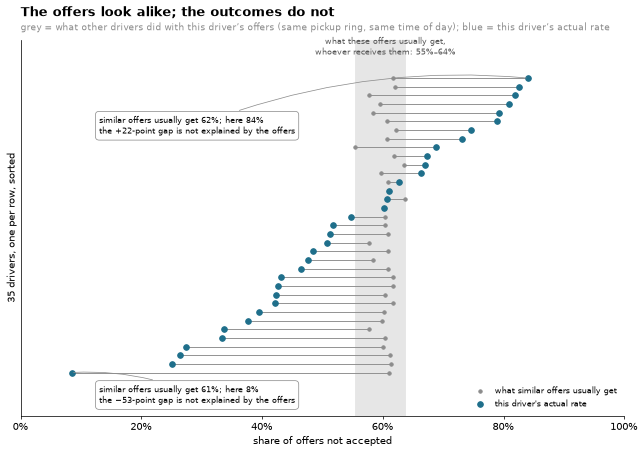

In [16]:
fig, ax = plt.subplots(figsize=(9.9, 7))
ax.axvspan(ranked.expected.min(), ranked.expected.max(), color=LIGHT, zorder=0)
ax.text(ranked.expected.mean(), len(ranked) + 1.4,
        f'what these offers usually get,\nwhoever receives them: '
        f'{ranked.expected.min():.0%}–{ranked.expected.max():.0%}',
        ha='center', va='bottom', fontsize=9, color='#555555')
ax.hlines(rows, ranked.expected, ranked.observed, color=GREY, lw=1)
ax.scatter(ranked.expected, rows, s=14, color=GREY, zorder=3,
           label='what similar offers usually get')
ax.scatter(ranked.observed, rows, s=38, color=ACCENT, zorder=3,
           label="this driver's actual rate")
# A boxed note on the top and the bottom driver.
for row, text_row, bend in [(len(ranked) - 1, len(ranked) - 6.5, -.12), (0, -2.6, .12)]:
    gap_label = f'{100 * gap_to_offers.iloc[row]:+.0f}'.replace('-', '−')       # e.g. +22, −53
    ax.annotate(f'similar offers usually get {ranked.expected.iloc[row]:.0%}; '
                f'here {ranked.observed.iloc[row]:.0%}\n'
                f'the {gap_label}-point gap is not explained by the offers',
                (ranked.observed.iloc[row], row),
                xytext=(.13, text_row), fontsize=9, va='center',
                bbox=dict(boxstyle='round,pad=.45', facecolor='white', edgecolor=GREY, lw=.8),
                arrowprops=dict(arrowstyle='-', color=GREY, lw=.8,
                                connectionstyle=f'arc3,rad={bend}'))
ax.set(xlim=(0, 1), ylim=(-5, len(ranked) + 3.4), yticks=[],
       xlabel='share of offers not accepted',
       ylabel=f'{len(ranked)} drivers, one per row, sorted')
pct(ax); ax.legend(loc='lower right', frameon=False, fontsize=9)
titled(ax, 'The offers look alike; the outcomes do not', subtitle)
plt.tight_layout(); plt.show()

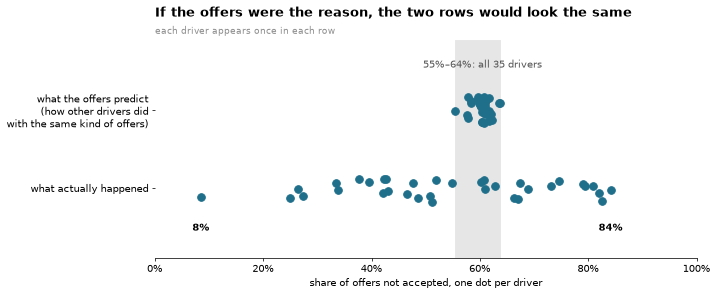

In [17]:
# Deck slide 3 uses this plainer version of the same comparison: two rows of dots on one axis.
jitter = np.random.default_rng(SEED).uniform(-.18, .18, (2, len(by_driver)))
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.axvspan(by_driver.expected.min(), by_driver.expected.max(), color=LIGHT, zorder=0)
ax.scatter(by_driver.expected, 1 + jitter[0], s=70, color=ACCENT, zorder=3)
ax.scatter(by_driver.observed, jitter[1], s=70, color=ACCENT, zorder=3)
ax.text(by_driver.expected.mean(), 1.55,
        f'{by_driver.expected.min():.0%}–{by_driver.expected.max():.0%}: '
        f'all {len(by_driver)} drivers',
        ha='center', fontsize=11, color='#555555')
for rate in (by_driver.observed.min(), by_driver.observed.max()):
    ax.text(rate, -.55, f'{rate:.0%}', ha='center', fontsize=11, weight='bold')
row_labels = ['what the offers predict\n(how other drivers did\nwith the same kind of offers)',
              'what actually happened']
ax.set_yticks([1, 0], row_labels)
ax.set(ylim=(-.9, 1.9), xlim=(0, 1), xlabel='share of offers not accepted, one dot per driver')
pct(ax)
ax.spines['left'].set_visible(False)
titled(ax, 'If the offers were the reason, the two rows would look the same',
       'each driver appears once in each row')
plt.tight_layout(); plt.show()

**No, it is not the trips.** Drivers are offered different trips, yet those trips predict **55–64%** not accepted for
all 35, against **8–84%** observed. **Request mix explains under 1% of the estimated between-driver variation here
(0.8%); at most a few per cent under every alternative tested offline** (finer grids, k-means zones, boosted model); a 4 km grid
barely changes how the drivers compare (rank correlation ≈ 0.99; `verification/robustness_checks.py`).

*How this was measured:* expected = other drivers' not-accepted rate in the same pickup ring × 6-hour block (ring only when
under 20 such offers), averaged over the driver's offers.

## Step 2. Does each driver have a consistent working pattern? — deck slide 4

*Backs deck slide 4 ("Is it a bad day?") and the appendix map slide.*

Split the six days in two: measure each driver on 17, 19, 21 August, then see whether that predicts the same driver on
18, 20, 22 August. Dispatch can only use this if it isn't simply about where the driver works.

In [18]:
# Split the six days in two and measure every driver on each half: set A is 17, 19, 21 August,
# set B is 18, 20, 22 August.
compared = offers[offers.driver_id.isin(main.index)]
halves = compared.groupby(['driver_id', 'day_set']).agg(
    offers=('not_accepted', 'size'),
    misses=('not_accepted', 'sum'),
    expected=('expected_not_accepted', 'sum'))
set_a, set_b = halves.xs('A', level='day_set'), halves.xs('B', level='day_set')

# A driver needs enough offers in both halves for the comparison to mean anything.
in_both = set_a.index.intersection(set_b.index)
set_a, set_b = set_a.loc[in_both], set_b.loc[in_both]
enough_in_both = (set_a.offers >= MIN_CELL) & (set_b.offers >= MIN_CELL)
set_a, set_b = set_a[enough_in_both], set_b[enough_in_both]

# Two views of each driver: the plain share not accepted, and that share minus what the offers
# themselves predicted. If the pattern survives the second view, it is not just the work they get.
plain = pd.DataFrame({'A': set_a.misses / set_a.offers,
                      'B': set_b.misses / set_b.offers})
pattern = pd.DataFrame({'A': (set_a.misses - set_a.expected) / set_a.offers,
                        'B': (set_b.misses - set_b.expected) / set_b.offers})
plain_r = plain.corr().loc['A', 'B']
pattern_r = pattern.corr().loc['A', 'B']
within_10_points = ((plain.A - plain.B).abs() <= .1).sum()

print(f'{len(plain)} drivers with ≥{MIN_CELL} offers on both sets of days | '
      f'17, 19, 21 Aug predicts 18, 20, 22 Aug: r = {plain_r:.2f} on the share not accepted, '
      f'r = {pattern_r:.2f} after allowing for the offers each driver received | '
      f'{within_10_points} of {len(plain)} within 10 points')

34 drivers with ≥20 offers on both sets of days | 17, 19, 21 Aug predicts 18, 20, 22 Aug: r = 0.83 on the share not accepted, r = 0.84 after allowing for the offers each driver received | 24 of 34 within 10 points


In [19]:
# Is it place? Put every offer near the centre on a 2 km square, then keep the busy squares.
near = offers[offers.x_km.between(-20, 20) & offers.y_km.between(-20, 20)].copy()
near['square_x'] = np.floor(near.x_km / 2)
near['square_y'] = np.floor(near.y_km / 2)

by_square = near.groupby(['square_x', 'square_y'])
grid = by_square.agg(offers=('not_accepted', 'size'), rate=('not_accepted', 'mean'),
                     vs_usual=('vs_usual', 'mean'), drivers_usual=('usual_rate', 'mean'))
grid = grid[grid.offers >= 30]

# How far square rates would wander on this many offers if nothing but noise separated them.
fleet_rate = offers.not_accepted.mean()
noise_variance = fleet_rate * (1 - fleet_rate) / grid.offers
area_chance_sd = np.sqrt(noise_variance.mean())

In [20]:
# Does a square's effect repeat? Measure each square on set A, then again on set B. The value
# measured is how its offers did against the usual rate of the drivers who happened to work there.
by_square_and_half = near.groupby(['square_x', 'square_y', 'day_set']).vs_usual
square_stats = by_square_and_half.agg(['mean', 'size'])
square_a = square_stats.xs('A', level='day_set').reindex(grid.index)
square_b = square_stats.xs('B', level='day_set').reindex(grid.index)

# Only squares with enough offers on each set of days can be compared with themselves.
enough_in_both = (square_a['size'] >= 15) & (square_b['size'] >= 15)
repeat = pd.DataFrame({'A': square_a['mean'][enough_in_both],
                       'B': square_b['mean'][enough_in_both]})

print(f'{len(grid)} squares | SD of square rates {grid.rate.std():.3f} vs '
      f'{area_chance_sd:.3f} from chance | correlation with the usual rate of the drivers '
      f'working there {grid.rate.corr(grid.drivers_usual):.2f} | '
      f'SD relative to own rate {grid.vs_usual.std():.3f} | '
      f"repeat across sets of days r = {repeat.corr().loc['A', 'B']:.2f} "
      f'({len(repeat)} squares with ≥15 offers on each)')

59 squares | SD of square rates 0.107 vs 0.073 from chance | correlation with the usual rate of the drivers working there 0.65 | SD relative to own rate 0.086 | repeat across sets of days r = 0.31 (43 squares with ≥15 offers on each)


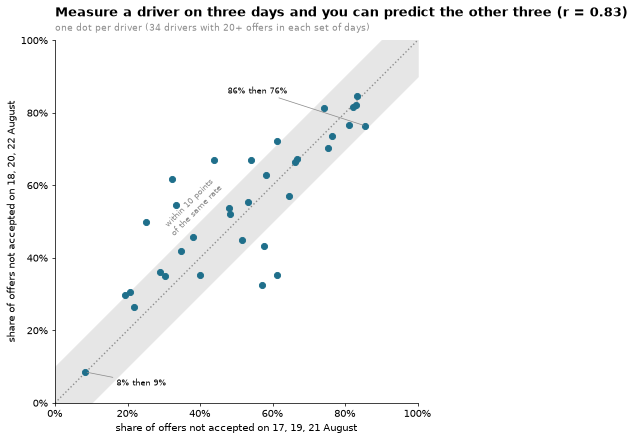

In [21]:
# One dot per driver: set A on the horizontal axis, set B on the vertical.
fig, ax = plt.subplots(figsize=(9.2, 6.8))
ax.fill_between((0, 1), (-.1, .9), (.1, 1.1), color=LIGHT, zorder=0)   # the within-10-points band
ax.plot((0, 1), (0, 1), linestyle=':', color=GREY)
ax.text(.4, .52, 'within 10 points\nof the same rate', color=GREY, fontsize=9,
        rotation=45, rotation_mode='anchor', ha='center', va='bottom')
ax.scatter(plain.A, plain.B, s=45, color=ACCENT, zorder=3)
# Label the steadiest extremes, top and bottom.
for driver, offset in [(plain.A.idxmax(), (-150, 38)), (plain.A.idxmin(), (34, -12))]:
    ax.annotate(f'{plain.A[driver]:.0%} then {plain.B[driver]:.0%}',
                (plain.A[driver], plain.B[driver]),
                xytext=offset, textcoords='offset points', fontsize=9, va='center',
                arrowprops=dict(arrowstyle='-', color=GREY, lw=.8))
ax.set(xlim=(0, 1), ylim=(0, 1), aspect='equal', anchor='W',
       xlabel='share of offers not accepted on 17, 19, 21 August',
       ylabel='share of offers not accepted on 18, 20, 22 August')
pct(ax); pct(ax, 'y')
headline = f'Measure a driver on three days and you can predict the other three (r = {plain_r:.2f})'
titled(ax, headline,
       f'one dot per driver ({len(plain)} drivers with {MIN_CELL}+ offers in each set of days)')
plt.tight_layout(); plt.show()

In [22]:
# The map needs dropoffs projected the same way pickups were in the loading cell, plus each
# offer's acceptance measured against the driver who received it.
drop_x = (dropoff_lon - CENTRE[1]) * np.cos(np.radians(CENTRE[0])) * 111.32
drop_y = (dropoff_lat - CENTRE[0]) * 110.574
driver_accept_rate = offers.driver_id.map(offers.groupby('driver_id').accepted.mean())
accepted_vs_usual = offers.accepted - driver_accept_rate
extent = (-26, 22, -16, 20)                                    # km east/west, km south/north

def points_label(value, position):
    '''Colour-bar tick for the right-hand map, where the value is an acceptance difference.
    Shown in percentage points so it reads the same way as the prose.'''
    return f'{100 * value:+.0f} pts' if value else '0'

point_ticks = FuncFormatter(points_label)

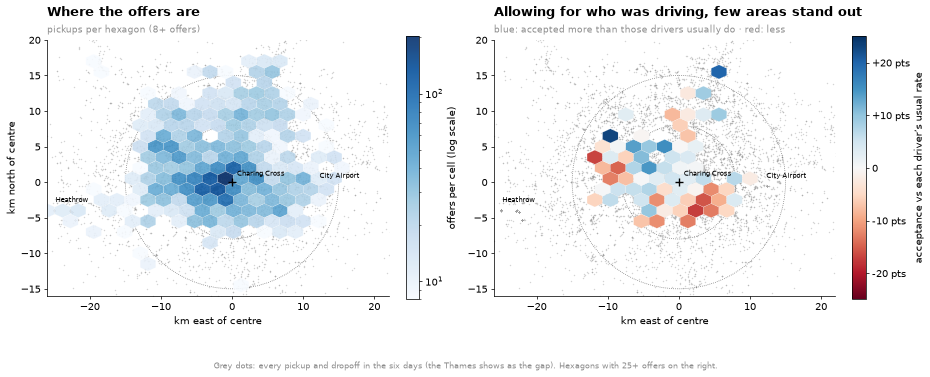

In [23]:
# Grey dots: every pickup and dropoff in the six days, which draws London with no map library.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax in axes:
    ax.scatter(np.r_[offers.x_km, drop_x], np.r_[offers.y_km, drop_y],
               s=2.5, color='#a0a0a0', alpha=.45, linewidths=0)
    ax.scatter(0, 0, marker='+', color='k', s=70, zorder=5)
    ax.text(.7, .9, 'Charing Cross', fontsize=8, zorder=5)
    ax.text(-22.5, -2.8, 'Heathrow', fontsize=8, ha='center')
    ax.text(12.3, .6, 'City Airport', fontsize=8)
    for radius in (3, 8, 15):                                  # the ring boundaries, in km
        ax.add_patch(plt.Circle((0, 0), radius, fill=False, linestyle=':', lw=.8, color='#666666'))
    ax.set(xlim=extent[:2], ylim=extent[2:], aspect='equal', xlabel='km east of centre')
axes[0].set_ylabel('km north of centre')

where = axes[0].hexbin(offers.x_km, offers.y_km, gridsize=22, mincnt=8, extent=extent,
                       cmap='Blues', norm=LogNorm(), linewidths=.2, edgecolors='white', alpha=.9)
who = axes[1].hexbin(offers.x_km, offers.y_km, C=accepted_vs_usual, reduce_C_function=np.mean,
                     gridsize=22, mincnt=25, extent=extent, cmap='RdBu',
                     norm=TwoSlopeNorm(0, -.25, .25), linewidths=.2, edgecolors='white')
fig.colorbar(where, ax=axes[0], shrink=.7, label='offers per cell (log scale)')
acceptance_bar = fig.colorbar(who, ax=axes[1], shrink=.7,
                              label='acceptance vs each driver’s usual rate')
acceptance_bar.ax.yaxis.set_major_formatter(point_ticks)
titled(axes[0], 'Where the offers are', 'pickups per hexagon (8+ offers)')
titled(axes[1], 'Allowing for who was driving, few areas stand out',
       'blue: accepted more than those drivers usually do · red: less')
fig.supxlabel('Grey dots: every pickup and dropoff in the six days (the Thames shows as the gap). '
              'Hexagons with 25+ offers on the right.', fontsize=9, color=GREY)
plt.show()

**Yes: each driver has a consistent working pattern.** Their share not accepted on 17, 19, 21 August predicts the other three days (**r = 0.83**, 34 drivers); allowing for the offers each driver received gives r = 0.84. This data cannot say whether that is availability, app habits or preference. **Area differences mostly follow each driver's usual rate:** square rates vary more than chance (SD 0.11 vs 0.07) but track those drivers' usual rate (0.65). Against each driver's own rate the spread drops to 0.09 and repeats weakly (0.31). Western and southern clusters persist: a lead.

*How this was measured:* 2 km squares with 30+ offers; the map shows acceptance.

## Step 3. Do drivers prefer different trips? — deck slides 5–6

*Backs deck slides 5 and 6 (the fleet average, then driver by driver).*

For each driver, compare long trips (≥ 8 straight-line km) with shorter ones, each against what was expected. A real
preference should show up again on the other set of days.

In [24]:
def long_short_gap(data, flag='long_trip', outcome='not_accepted', min_each=10):
    '''For each driver and each set of days: how much worse the driver does on flagged offers
    (long trips by default) than on the rest, each side measured against what those offers
    usually get. A positive gap means the driver accepts long trips less than their trips
    predict.'''
    compared = data[data.driver_id.isin(main.index)]
    totals = compared.groupby(['driver_id', 'day_set', flag]).agg(
        offers=(outcome, 'size'),
        observed=(outcome, 'sum'),
        expected=(f'expected_{outcome}', 'sum'))

    # Split the flagged offers from the rest, keeping only driver-days with enough of both.
    flagged, rest = totals.xs(True, level=flag), totals.xs(False, level=flag)
    in_both = flagged.index.intersection(rest.index)
    flagged, rest = flagged.loc[in_both], rest.loc[in_both]
    enough = (flagged.offers >= min_each) & (rest.offers >= min_each)
    flagged, rest = flagged[enough], rest[enough]

    # Observed minus expected on the flagged offers, less the same on all the other offers.
    flagged_gap = (flagged.observed - flagged.expected) / flagged.offers
    rest_gap = (rest.observed - rest.expected) / rest.offers
    gap_by_day_set = flagged_gap - rest_gap

    # One column per set of days; a driver missing either side drops out.
    return pd.DataFrame({'A': gap_by_day_set.xs('A', level='day_set'),
                         'B': gap_by_day_set.xs('B', level='day_set')}).dropna()

In [25]:
def stable_parts(driver_ids):
    '''How big the two repeatable parts of a driver's behaviour are. The covariance between set A
    and set B keeps only what repeats across the two halves, so noise drops out. Returns the SD of
    the overall driver difference, the SD of the trip-length swing on one offer, and the swing's
    share of the two. Reads pattern (step 2), gap and share_long from the cells around it.'''
    # A negative covariance means nothing repeated at all; treat it as zero, not a negative SD.
    pattern_variance = max(pattern.loc[driver_ids].cov().loc['A', 'B'], 0)
    gap_variance = max(gap.loc[driver_ids].cov().loc['A', 'B'], 0)

    # The gap is a difference between two groups of offers, so what it does to any one offer
    # depends on how often a long trip comes up at all.
    swing_variance = share_long * (1 - share_long) * gap_variance
    swing_share = swing_variance / (pattern_variance + swing_variance)
    return np.sqrt(pattern_variance), np.sqrt(swing_variance), swing_share

In [26]:
gap = long_short_gap(offers)
gap_r = gap.corr().loc['A', 'B']

# Chance benchmark. Shuffling the long/short label within each driver and set of days keeps that
# driver's own rate and their number of long trips exactly as they were, and destroys only the
# pairing between trip length and outcome. Doing it 1,000 times shows how large a repeat
# correlation luck alone produces; the real one has to beat those to mean anything.
rng = np.random.default_rng(SEED)
shuffled_r = []
for _ in range(1000):
    shuffled_flag = offers.groupby(['driver_id', 'day_set']).long_trip.transform(rng.permutation)
    shuffled_gap = long_short_gap(offers.assign(long_trip=shuffled_flag))
    shuffled_r.append(shuffled_gap.corr().loc['A', 'B'])
shuffled_r = np.array(shuffled_r)

# How often chance beat the real correlation, counting the observed value itself on both sides.
p_value = (1 + (shuffled_r >= gap_r).sum()) / 1001

print(f'{len(gap)} drivers | the long-vs-short gap repeats: r = {gap_r:.2f} | 1,000 shuffles: '
      f'95th percentile {np.quantile(shuffled_r, .95):.2f}, '
      f'largest {shuffled_r.max():.2f}, p = {p_value:.3f}')

30 drivers | the long-vs-short gap repeats: r = 0.77 | 1,000 shuffles: 95th percentile 0.32, largest 0.60, p = 0.001


In [27]:
# Does the gap survive other cut-offs for "long", another way of splitting the days, and each
# kind of miss taken on its own?
variants = {}
variants['≥ 5 straight-line km'] = long_short_gap(offers.assign(long_trip=offers.trip_km >= 5))
variants['≥ 12 straight-line km'] = long_short_gap(offers.assign(long_trip=offers.trip_km >= 12))

# Splitting the days into the first three and the last three, instead of alternating them.
early_late = pd.Series('B', index=offers.index)
early_late[offers.day <= 19] = 'A'
variants['first three days vs last three'] = long_short_gap(offers.assign(day_set=early_late))

variants['turn-downs only'] = long_short_gap(offers, outcome='turned_down')
variants['no responses only'] = long_short_gap(offers, outcome='no_response')

summary = {}
for name, result in variants.items():
    summary[name] = {'repeat r': result.corr().loc['A', 'B'], 'drivers': len(result)}
pd.DataFrame(summary).T

,repeat r,drivers
≥ 5 straight-line km,0.82,32.00
≥ 12 straight-line km,0.78,14.00
first three days vs last three,0.72,28.00
turn-downs only,0.73,30.00
no responses only,0.68,30.00


In [28]:
# Hidden in the average: the fleet-wide rate by trip length, then each driver's own lean.
bands = ['short\n(<3 km)', 'medium\n(3–8 km)', 'long\n(8+ km)']   # chart labels, straight-line km
banded = offers[offers.driver_id.isin(main.index)].copy()
banded['band'] = pd.cut(banded.trip_km, [0, 3, 8, np.inf], right=False, labels=bands)

# How each offer did against what other drivers did with similar offers, in points.
banded['vs_others'] = banded.not_accepted - banded.expected_not_accepted

# The fleet-wide rate in each band: the average that hides the disagreement between drivers.
fleet_by_band = banded.groupby('band', observed=True).not_accepted.mean()

In [29]:
# One row per driver, one column per band: how many offers, and how the driver did on them
# against other drivers with similar offers.
by_driver_band = banded.groupby(['driver_id', 'band'], observed=True).vs_others
band_stats = by_driver_band.agg(['size', 'mean'])
band_offers = band_stats['size'].unstack('band')
band_means = band_stats['mean'].unstack('band')

# Keep drivers with 10+ offers in every band, then read off the long-minus-short lean.
enough_in_every_band = (band_offers >= 10).all(axis=1)
by_band = band_means[enough_in_every_band]
lean = 100 * (by_band[bands[2]] - by_band[bands[0]])       # long minus short, in points
leaves_long = (lean >= 5).sum()
leaves_short = (lean <= -5).sum()
no_clear_lean = len(lean) - leaves_long - leaves_short

print('fleet share not accepted: short {:.1%}, medium {:.1%}, long {:.1%}'.format(*fleet_by_band),
      f'| {len(lean)} drivers with 10+ offers in every band:',
      f'{leaves_long} leave more long trips unaccepted (≥ +5 points), '
      f'{leaves_short} more short trips (≤ −5), {no_clear_lean} no clear lean')

fleet share not accepted: short 59.3%, medium 62.9%, long 61.7% | 35 drivers with 10+ offers in every band: 17 leave more long trips unaccepted (≥ +5 points), 15 more short trips (≤ −5), 3 no clear lean


In [30]:
# How often a long trip comes up for these drivers, which sets how much the swing can matter.
share_long = offers[offers.driver_id.isin(gap.index)].long_trip.mean()
pattern_sd, swing_sd, swing_share = stable_parts(gap.index)

# 90% interval on the swing's share: draw a new set of drivers, with replacement, 2,000 times.
rng = np.random.default_rng(SEED)
resampled_shares = []
for _ in range(2000):
    resampled_drivers = rng.choice(gap.index, len(gap.index))
    resampled_shares.append(stable_parts(resampled_drivers)[2])
low, high = np.quantile(resampled_shares, [.05, .95])

print(f'what repeats: overall driver difference SD {pattern_sd:.3f} | '
      f'trip-length swing on one offer SD {swing_sd:.3f} | '
      f'swing = {swing_share:.1%} of the two (90% interval {low:.0%}–{high:.0%})')

what repeats: overall driver difference SD 0.167 | trip-length swing on one offer SD 0.091 | swing = 22.7% of the two (90% interval 14%–34%)


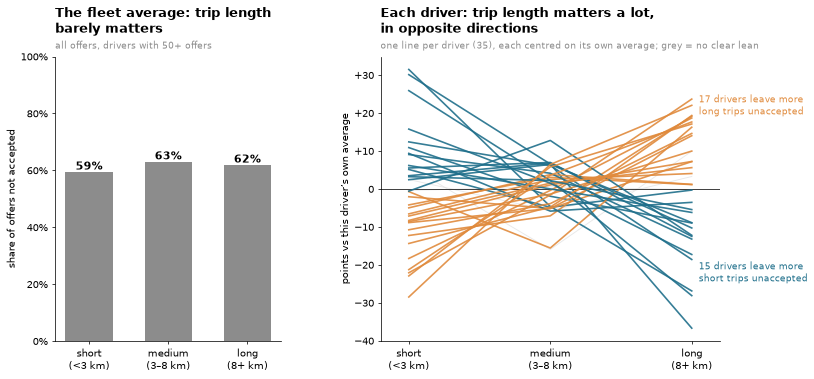

In [31]:
# Left: the fleet average by band. Right: the same drivers one line each, centred on their level.
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5.6),
                                  gridspec_kw={'width_ratios': [1, 1.5], 'wspace': .35})

left.bar(range(3), fleet_by_band, color=GREY, width=.6)
left.set_xticks(range(3), bands); left.set_ylim(0, 1); pct(left, 'y')
left.set_ylabel('share of offers not accepted')
for position, value in enumerate(fleet_by_band):
    left.text(position, value + .01, f'{value:.0%}', ha='center', fontsize=12, weight='bold')

centred = 100 * by_band.sub(by_band.mean(axis=1), axis=0)     # remove each driver's overall level
for driver, row in centred.iterrows():
    colour = ORANGE if lean[driver] >= 5 else ACCENT if lean[driver] <= -5 else LIGHT
    right.plot(range(3), row, color=colour, lw=1 if colour == LIGHT else 1.8,
               alpha=.9, zorder=1 if colour == LIGHT else 3)
right.axhline(0, color='k', lw=.8)
right.set_xticks(range(3), bands); right.set_xlim(-.2, 2.2)
right.yaxis.set_major_formatter(signed)
right.set_ylabel('points vs this driver’s own average')
right.text(2.05, 22, f'{leaves_long} drivers leave more\nlong trips unaccepted',
           color=ORANGE, fontsize=10, va='center')
right.text(2.05, -22, f'{leaves_short} drivers leave more\nshort trips unaccepted',
           color=ACCENT, fontsize=10, va='center')

titled(left, 'The fleet average: trip length\nbarely matters',
       'all offers, drivers with 50+ offers')
titled(right, 'Each driver: trip length matters a lot,\nin opposite directions',
       f'one line per driver ({len(lean)}), each centred on its own average; grey = no clear lean')
plt.show()

**Yes: drivers prefer different trips.** Of 35 drivers, 17 leave more long trips unaccepted and 15 more short ones (3 no clear lean), so the fleet average looks flat (59% short, 63% medium, 62% long). The gap repeats across days (**r ≈ 0.77,
30 drivers**, p ≈ 0.001; that test uses the 8 km long/short split), and on all ten day splits (0.71–0.79, offline). The overall
difference between drivers is bigger: about 17 points, against a trip-length swing of about 9 (22.7% of what repeats; 90% interval 14–34%).

*How this was measured:* chart: 10+ offers in every band; lean = long minus short, ±5 points. Test: labels shuffled within
driver and set of days, 1,000 times.

## Step 4. Two signals: availability and preference — deck slide 7

*Backs deck slide 7 ("Does it hold on days the model never saw?").*

Models, trained on 17–20 August and scored on 21–22 August, each add one
thing: the request, the driver, their last few minutes, their trip-length preference.

**In plain words.** The next two cells set up a fair test: can a model that has never seen 21–22
August predict what happened on those days? Everything is fitted on 17–20 August only. Inside those
training days, one more split is used to pick how hard the model should be held back from
over-fitting: the model is fitted on 17–19 August and tried on 20 August, at seven different
strengths, and the strength that predicts 20 August best is the one kept. That chosen model is then
refitted on all four training days and asked to predict each offer on 21–22 August. The score is log
loss — the penalty for being confidently wrong — so lower is better, and each model is reported by
how much it improves on the one before it.

In [32]:
def held_out_loss(inputs, outcome, rows):
    '''Log loss of each 21–22 Aug offer under a logistic model trained on 17–20 Aug; lower is
    better. The regularisation strength is chosen on 20 Aug only (fitting 17–19), then the model
    is refitted on all four days, so nothing about the test days reaches the fit.'''
    inputs = inputs.copy()
    # Scale the numeric inputs on the training days only, so the test days leak nothing.
    for column in ['log_km', 'log_min_since_offer', 'no_responses_15min']:
        if column in inputs:
            training = inputs[column][offers.day <= 20]
            inputs[column] = (inputs[column] - training.mean()) / training.std()

    def fit(strength, days):
        '''Fit the model at regularisation `strength` on the rows of interest within `days`.
        Called once per strength on 17–19 Aug to choose it, then once more on 17–20 Aug.'''
        fitting_rows = rows & days
        return LogisticRegression(C=strength, max_iter=2000).fit(inputs[fitting_rows],
                                                                 outcome[fitting_rows])

    validation, test_rows = rows & (offers.day == 20), rows & (offers.day >= 21)
    # Pick the strength that predicts 20 Aug best, having fitted on 17–19 Aug only.
    validation_loss = {}
    for strength in [.01, .03, .1, .3, 1, 3, 10]:
        predicted = fit(strength, offers.day <= 19).predict_proba(inputs[validation])[:, 1]
        validation_loss[strength] = log_loss(outcome[validation], predicted)
    best = min(validation_loss, key=validation_loss.get)

    probability = fit(best, offers.day <= 20).predict_proba(inputs[test_rows])[:, 1]
    test_outcome = outcome[test_rows]
    return -(test_outcome * np.log(probability) + (1 - test_outcome) * np.log(1 - probability))

In [33]:
def step_gains(state):
    '''For each outcome: how much each model improves held-out log loss over the model before it
    (the first row improves on a constant). The 90% interval resamples whole driver-days 1,000
    times, because offers within one driver's day are not independent.'''
    table = {}
    for name, (outcome, rows) in outcomes.items():
        test_outcome = outcome[rows & (offers.day >= 21)]
        # The model to beat: predict the training base rate for every test offer.
        base_rate = outcome[rows & (offers.day <= 20)].mean()
        loss = pd.DataFrame({'constant': -(test_outcome * np.log(base_rate)
                                           + (1 - test_outcome) * np.log(1 - base_rate))})
        for model, inputs in model_inputs(state).items():
            loss[model] = held_out_loss(inputs, outcome, rows)
        gain = -loss.diff(axis=1).iloc[:, 1:]          # each model against the one before it

        driver_day = (offers.driver_id + offers.day.astype(str))[gain.index]
        driver_days = [group.index for _, group in gain.groupby(driver_day)]
        rng = np.random.default_rng(SEED)
        resampled = []
        for _ in range(1000):
            picked = rng.integers(0, len(driver_days), len(driver_days))
            resampled.append(gain.loc[np.concatenate([driver_days[i] for i in picked])].mean())
        low, high = np.quantile(np.array(resampled), [.05, .95], axis=0)
        table[name] = [f'{mean:+.3f} [{lower:+.3f}, {upper:+.3f}]'
                       for mean, lower, upper in zip(gain.mean(), low, high)]
    return pd.DataFrame(table, index=gain.columns)

**In plain words.** The next three cells build four models that each add one ingredient, so the
value of each ingredient can be read off separately. Model A knows only the request: where it starts,
what time it is, how long the trip is and which product it is. Model B adds who the driver is, as one
yes/no column per driver. Model C adds what the driver has been doing in the last few minutes —
whether their previous offer went unanswered, how long ago it was, how many they have missed in the
past quarter hour, and whether they are still on a trip — counting only what dispatch could actually
have known at that moment, which is why an outcome is ignored until it is 60 seconds old. Model D
adds each driver's own response to trip length. The last cell runs all four against three outcomes
and prints the table of gains.

In [34]:
def recent_state(known_after=60):
    '''What dispatch could know about the driver's last few minutes when the offer goes out.
    A previous offer's outcome only counts once it is `known_after` seconds old; 0 seconds shows
    what timing leakage looks like.'''
    by_driver_id = offers.groupby('driver_id')
    seconds_since = by_driver_id.dispatched_datetime.diff().dt.total_seconds()
    known = seconds_since >= known_after

    # No-responses in the driver's last 15 minutes, less any so recent that dispatch would
    # not have heard about them yet.
    no_response_by_time = offers.set_index('dispatched_datetime').groupby('driver_id').no_response
    in_15min = no_response_by_time.rolling('900s', closed='left').sum().fillna(0).to_numpy()
    too_recent = 0
    if known_after:
        just_now = no_response_by_time.rolling(f'{known_after}s', closed='left').sum()
        too_recent = just_now.fillna(0).to_numpy()

    # On a trip if the driver's latest completed dropoff is still in the future. A missing dropoff
    # counts as long ago, so an unfinished trip never looks like an active one.
    dropoffs = offers.dropoff_trip_datetime.fillna(pd.Timestamp.min)
    previous_dropoff = dropoffs.groupby(offers.driver_id).shift()
    last_dropoff = previous_dropoff.groupby(offers.driver_id).cummax()
    return pd.DataFrame({
        'prev_no_response': by_driver_id.no_response.shift().eq(1) & known,
        'prev_turned_down': by_driver_id.turned_down.shift().eq(1) & known,
        'prev_taken': by_driver_id.not_accepted.shift().eq(0) & known,
        'log_min_since_offer': np.log1p(seconds_since.fillna(86400) / 60),
        'no_responses_15min': in_15min - too_recent,
        'on_trip': last_dropoff > offers.dispatched_datetime,
    }).astype(float)

In [35]:
def model_inputs(state):
    '''The four nested models, each a table of inputs for the logistic regression: A the request
    only, B adds who the driver is, C adds their recent state, D adds driver × trip length.
    Driver and category columns are 0/1 dummies.'''
    request_columns = ['pickup_ring', 'product', 'hour_bin']
    request_categories = pd.get_dummies(offers[request_columns], dtype=float)
    request = pd.concat([request_categories, offers[['log_km']],
                         offers.is_scheduled.astype(float)], axis=1)
    driver = pd.get_dummies(offers.driver_id, dtype=float)

    # Centre trip length on the training days, so each driver's × km column is a lean, not a level.
    centred_km = offers.log_km - offers.log_km[offers.day <= 20].mean()
    driver_by_length = driver.mul(centred_km, axis=0).add_suffix(' × km')

    with_driver = pd.concat([request, driver], axis=1)
    with_state = pd.concat([request, driver, state], axis=1)
    with_length = pd.concat([request, driver, state, driver_by_length], axis=1)
    return {'A request only': request,
            'B + driver': with_driver,
            'C + recent state': with_state,
            'D + driver × trip length': with_length}

In [36]:
everyone = pd.Series(True, index=offers.index)
outcomes = {'not accepted': (offers.not_accepted, everyone),
            'no response': (offers.no_response, everyone),
            'turned down, if the driver responded': (offers.turned_down, offers.no_response.eq(0))}

holdout = step_gains(recent_state(known_after=60))
# The same again with no 60-second rule, to show what timing leakage alone would buy.
leaky = step_gains(recent_state(known_after=0))

test_offers = {}
for name, (outcome, rows) in outcomes.items():
    test_offers[name] = int((rows & (offers.day >= 21)).sum())

leaky_state = leaky.loc['C + recent state'].to_dict()
print('test offers:', test_offers,
      '\nrecent state WITHOUT the 60-second rule (leaks timing):', leaky_state)
holdout

test offers: {'not accepted': 2372, 'no response': 2372, 'turned down, if the driver responded': 1393} 
recent state WITHOUT the 60-second rule (leaks timing): {'not accepted': '+0.008 [+0.003, +0.014]', 'no response': '+0.010 [+0.003, +0.017]', 'turned down, if the driver responded': '+0.002 [-0.003, +0.007]'}


,not accepted,no response,"turned down, if the driver responded"
A request only,"-0.012 [-0.021, -0.003]","-0.009 [-0.015, -0.002]","+0.006 [-0.011, +0.024]"
B + driver,"+0.057 [+0.040, +0.074]","+0.072 [+0.038, +0.108]","+0.172 [+0.135, +0.209]"
C + recent state,"+0.006 [-0.000, +0.011]","-0.001 [-0.007, +0.007]","+0.003 [-0.001, +0.007]"
D + driver × trip length,"+0.020 [+0.013, +0.028]","+0.002 [-0.006, +0.009]","+0.020 [+0.007, +0.033]"


In [37]:
def point_estimate(column):
    '''Turn cells like "+0.057 [+0.040, +0.074]" back into plain numbers, so the deck chart can
    show the point estimate on its own without the interval.'''
    return column.str.split(' ').str[0].astype(float)

gain_values = holdout.apply(point_estimate)

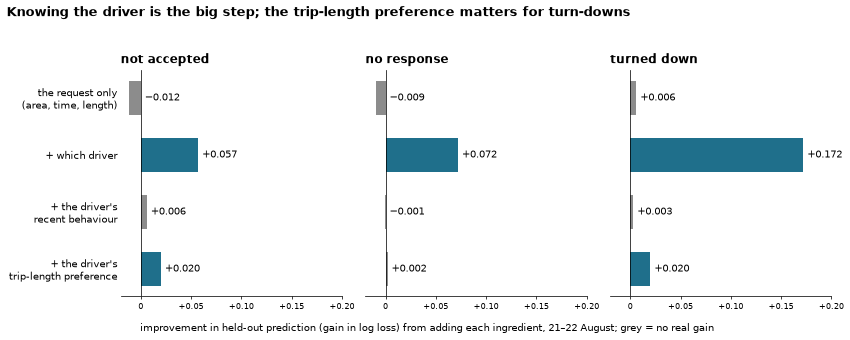

In [38]:
# Deck slide 7 shows the same table as bars: the gain each model adds, for each outcome.
labels = ['the request only\n(area, time, length)', '+ which driver',
          "+ the driver's\nrecent behaviour", "+ the driver's\ntrip-length preference"]
rows = np.arange(len(gain_values))[::-1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=True)
for ax, outcome in zip(axes, gain_values.columns):
    ax.barh(rows, gain_values[outcome], height=.6,
            color=[ACCENT if value > .01 else GREY for value in gain_values[outcome]])
    ax.axvline(0, color='k', lw=.8)
    for row, value in zip(rows, gain_values[outcome]):
        label = f'{value:+.3f}'.replace('-', '−')
        ax.text(max(value, 0) + .004, row, label, va='center', fontsize=11)
    ax.set_title(outcome.replace(', if the driver responded', ''),
                 fontsize=13, weight='bold', loc='left', pad=8)
    ax.set(xlim=(-.02, .2), xticks=[0, .05, .1, .15, .2])
    ax.set_xticklabels(['0', '+0.05', '+0.10', '+0.15', '+0.20'], fontsize=9)
    ax.spines['left'].set_visible(False); ax.tick_params(axis='y', length=0)
axes[0].set_yticks(rows, labels, fontsize=11)
fig.text(.5, -.03,
         'improvement in held-out prediction (gain in log loss) from adding each ingredient, '
         '21–22 August; grey = no real gain', ha='center', fontsize=11)
fig.suptitle('Knowing the driver is the big step; '
             'the trip-length preference matters for turn-downs',
             x=.01, ha='left', fontsize=14, weight='bold', y=1.04)
plt.tight_layout(); plt.show()

**Both: two driver-level signals.** The request alone is worse than a constant for not-accepted and no-response, and
indistinguishable from one for turn-downs; **knowing the driver is the big step**. **Turn-downs add a trip-length preference**
(+0.020 [0.007, 0.033]). **No-responses look mostly like availability:** trip length does not help predict them (+0.002),
though their long-vs-short difference repeats in step 3 (r 0.68). Recent state adds little.

*How this was measured:* entries are gains in held-out log loss over the row above; brackets are 90% intervals from resampling
driver-days. Recent state uses only what dispatch could know: a previous outcome counts once it is ≥ 60 s old.

**A lead on why:** the next cell asks whether turn-downs rise as a driver's day goes on, using two derived proxies.

In [39]:
# A lead, from two DERIVED PROXIES (the data has no shift, login, odometer or battery fields):
#   trip_miles_so_far_today = recorded distance_in_miles of the driver's earlier Finished trips
#     that calendar date (no pickup or repositioning miles)
#   hours_since_first_offer_today = hours since the driver's first offer that calendar date,
#     which is not the true start of their shift
# Splitting by calendar day is safe here: only 12 offers (0.2%) fall within 2 hours of the same
# driver's last offer before midnight.
date = offers.dispatched_datetime.dt.date
finished_miles = offers.distance_in_miles.where(offers.status == 'Finished', 0)

# Miles completed EARLIER today: the running total, less this trip's own miles.
miles_by_driver_day = finished_miles.groupby([offers.driver_id, date])
offers['trip_miles_so_far_today'] = miles_by_driver_day.cumsum() - finished_miles

first_offer = offers.groupby(['driver_id', date]).dispatched_datetime.transform('min')
hours_elapsed = (offers.dispatched_datetime - first_offer).dt.total_seconds() / 3600
offers['hours_since_first_offer_today'] = hours_elapsed

# Only offers the driver actually answered; a silence says nothing about willingness.
responded = offers[offers.no_response == 0].copy()
own_turn_down_rate = responded.driver_id.map(responded.groupby('driver_id').turned_down.mean())
responded['vs_own_rate'] = 100 * (responded.turned_down - own_turn_down_rate)

In [40]:
def thirds(values):
    '''Split a column into lowest / middle / highest third, each holding the same number of offers.
    Ranked with method='first' so ties do not unbalance the groups.'''
    names = ['lowest third', 'middle third', 'highest third']
    return pd.qcut(values.rank(method='first'), 3, labels=names)

# Turn-downs against each driver's own rate, by third of each proxy, split by trip length.
thirds_by_proxy = {proxy: responded.pivot_table(index=thirds(responded[proxy]), columns='long_trip',
                                                values='vs_own_rate', observed=True)
                   for proxy in ['hours_since_first_offer_today', 'trip_miles_so_far_today']}
lead_table = (pd.concat(thirds_by_proxy)
              .rename(columns={False: 'shorter trips', True: 'long trips'})
              .rename_axis(index=['derived proxy', 'third of offers'], columns=None))

**In plain words.** The next two cells ask whether a driver becomes more likely to refuse as their
day wears on. The data has no shift or battery records, so two stand-ins are derived: the miles the
driver has already completed that calendar date, and the hours since their first offer that date.
Only offers the driver actually answered are used, because a silence says nothing about willingness.
A logistic regression then predicts "turned down" from those two stand-ins, with one yes/no column
per driver and per three-hour bin so that the comparison happens within a driver rather than between
drivers. A term for long trip × miles asks whether the effect is different on long trips. The
intervals come from redrawing whole driver-days, because two offers in the same driver's day are not
independent.

In [41]:
def lead_fit(data):
    '''Logistic regression (C = 1) of "turned down" on driver, 3-hour bin, long trip, the two
    and long trip × miles. Returns the four coefficients of interest; called again on resampled
    driver-days to get the 90% intervals.'''
    inputs = pd.concat([pd.get_dummies(data.driver_id, dtype=float),
                        pd.get_dummies(data.hour_bin, dtype=float)], axis=1)
    inputs['long trip'] = data.long_trip.astype(float)
    inputs['trip miles so far today / 50'] = data.trip_miles_so_far_today / 50
    inputs['long trip × miles / 50'] = inputs['long trip'] * inputs['trip miles so far today / 50']
    inputs['hours since first offer today / 4'] = data.hours_since_first_offer_today / 4
    fitted = LogisticRegression(C=1, max_iter=3000).fit(inputs, data.turned_down)
    return pd.Series(fitted.coef_[0], index=inputs.columns).iloc[-4:]

In [42]:
# 90% interval: resample whole driver-days, because two offers in the same driver's day are
# not independent of each other.
by_driver_day = responded.groupby([responded.driver_id, date[responded.index]])
driver_days = [group.index for _, group in by_driver_day]
rng = np.random.default_rng(SEED)
resampled = []
for _ in range(300):
    picked = rng.integers(0, len(driver_days), len(driver_days))
    resampled.append(lead_fit(responded.loc[np.concatenate([driver_days[i] for i in picked])]))
resampled = pd.DataFrame(resampled)

lead = pd.DataFrame({'coefficient': lead_fit(responded),
                     '5%': resampled.quantile(.05),
                     '95%': resampled.quantile(.95)})
base_rate = responded.turned_down.mean()
# Turn the logit slope into percentage points, read at the overall turn-down rate.
miles_effect = 100 * lead.coefficient.iloc[1] * base_rate * (1 - base_rate)
print(f'{len(responded):,} responded offers, {base_rate:.0%} turned down | '
      f'+50 trip miles ≈ {miles_effect:+.0f} points | '
      f"first table: turn-downs vs the driver's own rate, in points")
display(lead_table.round(0).astype(int), lead)

3,206 responded offers, 32% turned down | +50 trip miles ≈ +9 points | first table: turn-downs vs the driver's own rate, in points


shorter trips  long trips
derived proxy                 third of offers                           
hours_since_first_offer_today lowest third                -5          -1
                              middle third                 1           3
                              highest third                2           1
trip_miles_so_far_today       lowest third                -5          -3
                              middle third                 1           4
                              highest third                2           1

,coefficient,5%,95%
long trip,0.27,-0.04,0.61
trip miles so far today / 50,0.41,0.24,0.77
long trip × miles / 50,-0.33,-0.69,-0.01
hours since first offer today / 4,0.00,-0.22,0.09


Drivers turn down more trips as their completed-trip miles today build up (about +9 points per 50 miles on shorter trips, less
on long ones), but not with time since their first offer: these derived proxies do not explain the long/short preference. The
mileage effect hints at something that depletes with driving, such as battery charge or fatigue. It's a lead, not a finding: the
data has no shift, battery or charging records, and these miles exclude pickup and repositioning. Battery and shift logs would
settle it.

## Step 5. Could dispatch use this without giving anyone more work? — deck slide 8

*Backs deck slide 8 (the prototype router).*

A prototype router, trained on 17–20 August: **by driver only** (ring, straight-line km, time, driver); **by driver and trip** adds
driver × km. Candidates: drivers offered something in the same ring within ±10 minutes and not on a trip, plus the actual
driver. Drivers at their actual offer count are skipped.

**In plain words.** The next three cells build a prototype dispatcher and ask what it would have
done differently. A model is trained on 17–20 August to answer one question: would this particular
driver accept this particular offer? It sees the pickup ring, the time of day, the trip length and
one yes/no column per driver; the second version also gets driver × trip length, which is what lets
it learn that some drivers prefer short trips and others long ones. Then, for each offer on the two
held-out days, a candidate list is assembled: the driver who really got it, plus anyone else who was
offered something in the same ring within ten minutes and was not mid-trip. That candidate list is a
rough stand-in, because the real one is not in the data.

In [43]:
# Prototype router. Outcome: the driver accepted. Train 17–20 Aug; test 21–22 Aug,
# restricted to drivers seen in training and taken in time order.
train = offers[offers.day <= 20]
known_drivers = sorted(train.driver_id.unique())
test = offers[(offers.day >= 21) & offers.driver_id.isin(known_drivers)]
test = test.sort_values('dispatched_datetime')
ring_and_hour = pd.get_dummies(offers[['pickup_ring', 'hour_bin']], dtype=float)
km_scaled = (offers.log_km - train.log_km.mean()) / train.log_km.std()
finished_trips = offers[offers.status == 'Finished']

def router_inputs(offer_ids, driver_ids, with_trip_length):
    '''Inputs for "would THIS driver accept THIS offer": pickup ring, 3-hour bin, straight-line km
    and one 0/1 column per driver. with_trip_length adds driver × km, which is what lets the model
    learn that some drivers prefer shorter or longer trips.'''
    who = np.equal.outer(np.asarray(driver_ids), known_drivers).astype(float)
    km = km_scaled[offer_ids].to_numpy()[:, None]
    blocks = [ring_and_hour.loc[offer_ids].to_numpy(), km, who]
    if with_trip_length:
        blocks.append(who * km)
    return np.hstack(blocks)

In [44]:
def nearby_candidates(offer):
    '''Who could plausibly have taken this offer: the actual driver first, then anyone offered
    something in the same pickup ring within 10 minutes who was not on a trip at that moment.
    A rough stand-in for the real candidate list, which is not in the data.'''
    seconds_apart = (test.dispatched_datetime - offer.dispatched_datetime).dt.total_seconds().abs()
    nearby = test[(test.pickup_ring == offer.pickup_ring) & (seconds_apart <= 600)]
    others = []
    for driver in sorted(nearby.driver_id.unique()):
        driver_trips = finished_trips[finished_trips.driver_id == driver]
        on_trip = ((driver_trips.order_accepted_timestamp < offer.dispatched_datetime)
                   & (driver_trips.dropoff_trip_datetime > offer.dispatched_datetime)).any()
        if driver != offer.driver_id and not on_trip:
            others.append(driver)
    return [offer.driver_id] + others

In [45]:
models = {}
for name, with_trip_length in [('by driver only', False), ('by driver and trip', True)]:
    inputs = router_inputs(train.index, train.driver_id, with_trip_length)
    models[name] = LogisticRegression(C=0.3, max_iter=3000).fit(inputs, train.accepted)

candidates = {offer_id: nearby_candidates(offer) for offer_id, offer in test.iterrows()}
sizes = pd.Series({offer_id: len(nearby) for offer_id, nearby in candidates.items()})
print(f'{len(test):,} test offers, {test.driver_id.nunique()} drivers | '
      f'median candidates {sizes.median():.0f} | offers with ≥2: {(sizes >= 2).mean():.0%}')

2,221 test offers, 35 drivers | median candidates 2 | offers with ≥2: 66%


**In plain words.** The next three cells replay the two held-out days under different routing rules
and score each one. Offers are handed out in time order, and each rule picks one driver from that
offer's candidate list: keep the driver who really got it, pick at random, or pick whichever
candidate the model rates highest. The workload cap is what makes the comparison fair — without it a
router can simply pile work onto the drivers who accept most, which raises acceptance by giving
people more to do rather than by matching better. Two caps are shown: nobody exceeds the number of
offers they actually received, and the stricter rule that nobody is ever more than three offers
ahead of the work that came their way. Every rule is then scored by both models, so no rule is
judged only by the model that chose it.

In [46]:
# Predicted acceptance for every offer × candidate driver, under both models.
offer_driver_pairs = [(offer_id, driver) for offer_id, drivers_nearby in candidates.items()
                      for driver in drivers_nearby]
pairs = pd.DataFrame(offer_driver_pairs, columns=['offer', 'driver'])
for name, with_trip_length in [('by driver only', False), ('by driver and trip', True)]:
    inputs = router_inputs(pairs.offer, pairs.driver, with_trip_length)
    pairs[name] = models[name].predict_proba(inputs)[:, 1]
score = pairs.set_index(['offer', 'driver']).to_dict('index')
workload = test.driver_id.value_counts()          # each driver's actual number of test offers

In [47]:
def route(policy, slack=None):
    '''Send each test offer, in time order, to one of its candidates. slack=None: nobody gets
    more offers than they actually had over the two days, and if nobody nearby has room the
    offer stays put. slack=k: nobody is ever more than k offers ahead of their real workload.'''
    given = dict.fromkeys(workload.index, 0)      # offers this policy has handed each driver
    seen = dict.fromkeys(workload.index, 0)       # offers that actually came to each driver
    rng = np.random.default_rng(SEED)
    chosen = {}
    for offer_id, drivers_nearby in candidates.items():
        seen[drivers_nearby[0]] += 1
        # Who still has room, under whichever workload cap is in force.
        free = []
        for driver in drivers_nearby:
            if slack is None:
                has_room = given[driver] < workload[driver]
            else:
                has_room = given[driver] < seen[driver] + slack
            if has_room:
                free.append(driver)
        if policy == 'actual dispatch' or not free:
            pick = drivers_nearby[0]
        elif policy == 'random nearby driver':
            pick = rng.choice(free)
        else:
            pick = max(free, key=lambda driver: score[(offer_id, driver)][policy])
        given[pick] += 1
        chosen[offer_id] = pick
    return pd.Series(chosen)

In [48]:
def scored(assignment, model):
    '''Average predicted acceptance of an assignment, judged by one of the two router models.
    Every policy is scored by both, so none is judged only by the model that chose it.'''
    return np.mean([score[pair][model] for pair in assignment.items()])

routes = {policy: route(policy) for policy in ['actual dispatch', 'random nearby driver',
                                               'by driver only', 'by driver and trip']}
routes['by driver only, cap that holds (≤ 3 ahead)'] = route('by driver only', slack=3)
routes['by driver and trip, cap that holds (≤ 3 ahead)'] = route('by driver and trip', slack=3)

summary = {}
for policy, assignment in routes.items():
    given = assignment.value_counts().reindex(workload.index, fill_value=0)
    extra_work = (given - workload).clip(lower=0)
    summary[policy] = {'scored by driver+trip model': scored(assignment, 'by driver and trip'),
                       'scored by driver-only model': scored(assignment, 'by driver only'),
                       'drivers used': assignment.nunique(),
                       'offers moved': (assignment != test.driver_id).mean(),
                       'work shifted': extra_work.sum() / len(test)}
router_table = pd.DataFrame(summary).T

In [49]:
moved = routes['by driver and trip'] != test.driver_id
predicted_for_assigned = np.mean([score[(offer_id, test.driver_id[offer_id])]['by driver and trip']
                                  for offer_id in moved[moved].index])
print(f'accepted on the test days: {test.accepted.mean():.1%} | '
      f'offers the driver-and-trip router kept: {test.accepted[~moved].mean():.1%} accepted '
      f'({(~moved).sum():,}) | would have moved: {test.accepted[moved].mean():.1%} '
      f'({moved.sum():,}; predicted for the assigned driver {predicted_for_assigned:.1%})')

trip_model_score = router_table['scored by driver+trip model']
driver_model_score = router_table['scored by driver-only model']
print('predicted acceptance, to one decimal:',
      {policy: f'{100 * trip_model_score[policy]:.1f}% '
               f'({100 * driver_model_score[policy]:.1f}% by the driver-only model)'
       for policy in router_table.index})
print('gain in points with the cap that holds:',
      {policy: f'{100 * (trip_model_score[policy] - trip_model_score.iloc[0]):+.1f} '
               f'by the driver-and-trip model, '
               f'{100 * (driver_model_score[policy] - driver_model_score.iloc[0]):+.1f} '
               f'by the driver-only model'
       for policy in trip_model_score.index[4:]})

percent_columns = ['scored by driver+trip model', 'scored by driver-only model',
                   'offers moved', 'work shifted']
as_percent = {column: router_table[column].map('{:.0%}'.format) for column in percent_columns}
display(router_table.assign(**as_percent).astype({'drivers used': int}))

accepted on the test days: 39.3% | offers the driver-and-trip router kept: 43.9% accepted (1,378) | would have moved: 31.7% (843; predicted for the assigned driver 31.6%)
predicted acceptance, to one decimal: {'actual dispatch': '37.1% (37.2% by the driver-only model)', 'random nearby driver': '37.1% (37.2% by the driver-only model)', 'by driver only': '39.5% (39.8% by the driver-only model)', 'by driver and trip': '41.2% (39.4% by the driver-only model)', 'by driver only, cap that holds (≤ 3 ahead)': '38.3% (38.4% by the driver-only model)', 'by driver and trip, cap that holds (≤ 3 ahead)': '39.5% (38.3% by the driver-only model)'}
gain in points with the cap that holds: {'by driver only, cap that holds (≤ 3 ahead)': '+1.2 by the driver-and-trip model, +1.2 by the driver-only model', 'by driver and trip, cap that holds (≤ 3 ahead)': '+2.4 by the driver-and-trip model, +1.2 by the driver-only model'}


,scored by driver+trip model,scored by driver-only model,drivers used,offers moved,work shifted
actual dispatch,37%,37%,35,0%,0%
random nearby driver,37%,37%,35,39%,4%
by driver only,40%,40%,35,38%,10%
by driver and trip,41%,39%,35,38%,8%
"by driver only, cap that holds (≤ 3 ahead)",38%,38%,35,10%,4%
"by driver and trip, cap that holds (≤ 3 ahead)",39%,38%,35,15%,4%


In [50]:
# Deck slide 8. Each bar runs from the more cautious of the two scorings to the other.
names = {'actual dispatch': 'Actual dispatch',
         'random nearby driver': 'Random nearby driver',
         'by driver only': 'Route by driver only,\nwork free to drift',
         'by driver only, cap that holds (≤ 3 ahead)':
             'Route by driver only,\nworkload held near-equal',
         'by driver and trip, cap that holds (≤ 3 ahead)':
             'Route by driver and trip,\nworkload held near-equal'}
policies = list(names)
bar_low = np.minimum(trip_model_score[policies], driver_model_score[policies])
bar_high = np.maximum(trip_model_score[policies], driver_model_score[policies])
leaky_cap = trip_model_score['by driver and trip']      # same router, under the cap that leaks

def bar_label(policy):
    '''Text beside one bar: the predicted share, as a range where the two scorings disagree,
    followed by the gain over actual dispatch in whole points.'''
    share_low, share_high = f'{bar_low[policy]:.0%}', f'{bar_high[policy]:.0%}'
    share = share_low if share_low == share_high else f'{share_low}–{share_high}'
    if policy == 'actual dispatch':
        return share
    gains = sorted(100 * (scoring[policy] - scoring['actual dispatch'])
                   for scoring in (trip_model_score, driver_model_score))
    whole = [int(round(gain)) for gain in gains]
    if gains[1] - gains[0] < 1:                 # show a range only where the scorings differ
        return f"{share}  ({whole[0]:+d} point{'s' * (whole[0] != 1)})"
    return f'{share}  ({whole[0]:+d} to {whole[1]:+d} before the baseline below)'

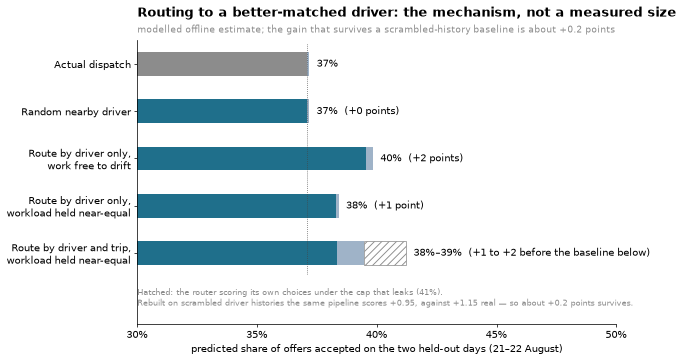

In [51]:
rows = np.arange(len(names))[::-1]                          # first policy at the top
fig, ax = plt.subplots(figsize=(9.9, 5.6))
ax.barh(rows, bar_low, height=.5, color=[GREY] + [ACCENT] * 4, zorder=2)
ax.barh(rows, bar_high - bar_low, height=.5, left=bar_low, color=BLUE_GREY, zorder=2)
ax.barh(rows[-1], leaky_cap - bar_high.iloc[-1], height=.5, left=bar_high.iloc[-1],
        color='white', edgecolor=GREY, hatch='///', lw=.8, zorder=2)
ax.vlines(trip_model_score['actual dispatch'], -.45, len(names) - .55,
          color='#444444', lw=.8, linestyle=':', zorder=3)   # stops above the footnote
for row, policy in zip(rows, names):
    bar_end = max(bar_high[policy], leaky_cap if row == rows[-1] else 0)
    ax.annotate(bar_label(policy), (bar_end, row), xytext=(8, 0), textcoords='offset points',
                va='center', fontsize=11)
ax.text(.3, -.95,
        f'Hatched: the router scoring its own choices under the cap that leaks ({leaky_cap:.0%}).\n'
        'Rebuilt on scrambled driver histories the same pipeline scores +0.95, against +1.15 real '
        '— so about +0.2 points survives.',
        fontsize=9, color=GREY, va='center')
ax.set_yticks(rows, list(names.values()))
ax.set(xlim=(.3, .5), ylim=(-1.5, len(names) - .5), xticks=np.arange(.3, .51, .05))
ax.set_xlabel('predicted share of offers accepted on the two held-out days (21–22 August)')
pct(ax)
titled(ax, 'Routing to a better-matched driver: the mechanism, not a measured size',
       'modelled offline estimate; the gain that survives a scrambled-history baseline '
       'is about +0.2 points')
plt.tight_layout(); plt.show()

**Possibly: it needs a live test.** Predicted acceptance: 37.1% for actual dispatch and a random nearby driver, 39.5% by driver
only, 41.2% by driver and trip. **My first estimate was that +4 points. A router built on scrambled driver histories scored itself
just as well (+4.4 on average over 20 rebuilds; `verification/router_checks.py`), so the model was flattering itself**; its cap
also leaks (8% of work shifts to drivers who accept more). With a cap that holds (≤ 3 offers ahead), by driver and trip gains
+2.4 points, +1.2 by the driver-only model.

**Running the scrambled router through that same capped, cross-graded pipeline shows the correction was incomplete: it scores
+0.95 on average (range +0.72 to +1.15) against +1.15 real, so only about +0.2 points survives** — at the top edge of what
scrambled histories produce, not clearly beyond it. The cross-grading does not protect as much as it looks: both models are
nested and share the same per-driver effect, and on a given offer that effect is the only thing separating candidates, so
they agree about a driver whether or not the history belongs to them. Grading the scrambled routes with the *real* models
instead drops the gain to about zero (+0.05, range −0.24 to +0.32), which is what shows the remainder is construction rather
than signal.

**So the router demonstrates the mechanism, not its size.** The evidence that the lever exists is the held-out test in step 4;
what routing is worth can only be measured by an A/B test at equal workload. Moved offers were accepted 32%, kept 44%.

## Step 6. What's a trip worth? — deck slide 9

*Backs deck slide 9 ("Where is a salaried minute worth most?").*

What do fares depend on?

In [52]:
# Finished trips with a fare; linear regression, 5-fold cross-validated R².
# "Airport" here is a product label on the category, not a zone.
airport = offers.category.str.contains('Airport|Heathrow|Stansted|Gatwick|Luton')
trips = offers[(offers.status == 'Finished') & (offers.trip_price_in_pound > 0)]
fare = trips.trip_price_in_pound
is_airport_trip = airport[trips.index]

# Two sets of inputs: recorded miles and minutes alone, then with start time and the airport label.
basic = trips[['distance_in_miles', 'ride_duration_in_min']]
start_block = trips.dispatched_datetime.dt.hour // 3 * 3
start_hour = pd.get_dummies(start_block, prefix='starts', dtype=float)
start_hour = start_hour.iloc[:, 1:]        # 00–03 dropped, so the other bins compare with it
full = pd.concat([basic, start_hour, is_airport_trip.astype(float).rename('airport category')],
                 axis=1)

# The same five folds for both input sets, so the two R² values are comparable.
folds = KFold(5, shuffle=True, random_state=SEED)
fare_r2 = {}
for name, inputs in [('miles + minutes', basic), ('+ 3-hour bins + airport', full)]:
    scores = cross_val_score(LinearRegression(), inputs, fare, cv=folds, scoring='r2')
    fare_r2[name] = scores.mean()
basic_fit = LinearRegression().fit(basic, fare)
full_fit = LinearRegression().fit(full, fare)

# How much of finished-trip revenue the airport label accounts for.
fare_revenue = fare.groupby(is_airport_trip).sum()
airport_revenue_share = fare_revenue[True] / fare_revenue.sum()

In [53]:
print(f'{len(trips):,} finished trips | cross-validated R²:',
      {name: round(value, 3) for name, value in fare_r2.items()})
print(f'miles + minutes: £{basic_fit.intercept_:.2f} + £{basic_fit.coef_[0]:.2f} per mile '
      f'+ £{basic_fit.coef_[1]:.2f} per minute | airport-category offers: '
      f'{airport.sum()} ({airport.mean():.0%} of offers, '
      f'{airport_revenue_share:.1%} of finished-trip revenue)')

# What each input adds to the fare, in pounds, once miles and minutes are accounted for.
fare_terms = pd.Series(full_fit.coef_, index=full.columns).round(2)
fare_terms.to_frame('£ added')

1,604 finished trips | cross-validated R²: {'miles + minutes': np.float64(0.876), '+ 3-hour bins + airport': np.float64(0.895)}
miles + minutes: £3.99 + £0.92 per mile + £0.21 per minute | airport-category offers: 280 (5% of offers, 17.6% of finished-trip revenue)


,£ added
distance_in_miles,0.75
ride_duration_in_min,0.23
starts_3,3.24
starts_6,1.83
starts_9,-1.43
starts_12,-0.04
starts_15,-0.11
starts_18,-1.01
starts_21,-0.36
airport category,6.58


In [54]:
# Deck slide 9. Odysse's drivers are paid for their time, so value per MINUTE of driving
# matters, not value per trip.
trips_timed = trips[trips.ride_duration_in_min > 0].copy()
# Label each trip by product, except that airport-category trips get a label of their own.
is_airport = airport[trips_timed.index]
trips_timed['kind'] = np.where(is_airport, 'Airport-category', trips_timed['product'])

def per_minute(frame, key):
    '''Fare per minute of driving for each group: total fare divided by total ride minutes.
    Totals rather than the average of per-trip ratios, so every minute counts the same.'''
    totals = frame.groupby(key).agg(trips=('trip_price_in_pound', 'size'),
                                    fare=('trip_price_in_pound', 'sum'),
                                    minutes=('ride_duration_in_min', 'sum'))
    totals['per_minute'] = totals.fare / totals.minutes
    return totals

by_kind = per_minute(trips_timed, 'kind')
by_kind = by_kind[by_kind.trips >= 30].sort_values('per_minute')     # labels with 30+ trips
start_block = trips_timed.dispatched_datetime.dt.hour // 3 * 3
by_start = per_minute(trips_timed, start_block)
all_trips = trips_timed.trip_price_in_pound.sum() / trips_timed.ride_duration_in_min.sum()

print(f'all finished trips: £{all_trips:.2f} of fare per minute of driving | by product label:',
      {kind: f'£{value:.2f}' for kind, value in by_kind.per_minute.items()})
start_labels = {f'{hour:02d}–{hour + 3:02d}': f'£{value:.2f}'
                for hour, value in by_start.per_minute.items()}
print('by start time:', start_labels)

def pounds_label(value, position):
    '''Tick label for the two fare-per-minute axes: pounds and pence, e.g. £0.72.
    Both panels use it so their axes read the same way.'''
    return f'£{value:.2f}'

pounds = FuncFormatter(pounds_label)

all finished trips: £0.57 of fare per minute of driving | by product label: {'Wait and Save': '£0.48', 'Bolt': '£0.54', 'Comfort': '£0.63', 'Bolt Priority': '£0.65', 'Airport-category': '£0.72'}
by start time: {'00–03': '£0.70', '03–06': '£0.90', '06–09': '£0.71', '09–12': '£0.52', '12–15': '£0.56', '15–18': '£0.54', '18–21': '£0.54', '21–24': '£0.58'}


In [55]:
# Where the fleet's hours actually sit, for the closing line on deck slide 9. A "driver-block" is
# one driver, one 3-hour block, one date with at least one offer: the closest stand-in for
# availability, because the data has no shift or login records.
block = offers.dispatched_datetime.dt.hour // 3 * 3
offer_date = offers.dispatched_datetime.dt.date
driver_blocks = pd.DataFrame({'driver_id': offers.driver_id, 'block': block, 'date': offer_date})
driver_blocks = driver_blocks.drop_duplicates()
active_blocks = driver_blocks.groupby('block').size()      # distinct driver-days active per block
activity_share = active_blocks / active_blocks.sum()

def fare_per_minute(first_block, last_block):
    '''Fare per minute of driving over the finished trips that start in a run of 3-hour blocks.
    Totals rather than the average of per-trip ratios, the same way per_minute works above.'''
    in_window = block[trips_timed.index].between(first_block, last_block)
    window = trips_timed[in_window]
    return window.trip_price_in_pound.sum() / window.ride_duration_in_min.sum()

busy_rate, early_rate = fare_per_minute(9, 18), fare_per_minute(3, 6)
print(f'where the capacity is: {activity_share.loc[9:18].sum():.0%} of driver activity is '
      f'9am–9pm (earning £{busy_rate:.2f}/min); {activity_share.loc[3:6].sum():.0%} is 3–9am '
      f'(earning £{early_rate:.2f}/min)')

where the capacity is: 73% of driver activity is 9am–9pm (earning £0.54/min); 13% is 3–9am (earning £0.73/min)


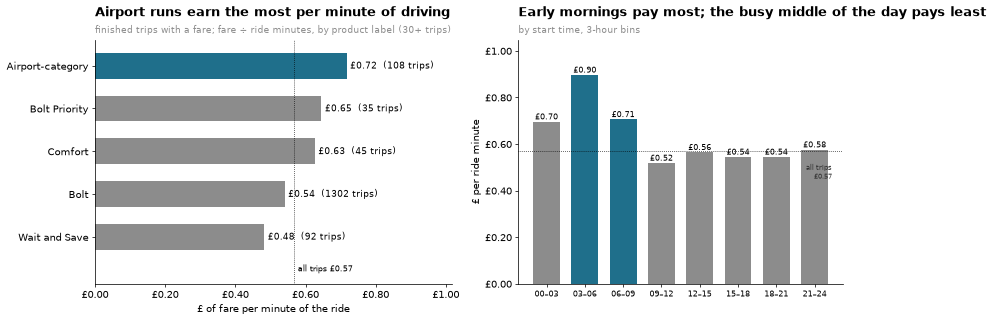

In [56]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.1, 1]})

left.barh(by_kind.index, by_kind.per_minute, height=.6,
          color=[ACCENT if kind == 'Airport-category' else GREY for kind in by_kind.index])
for row, (kind, values) in enumerate(by_kind.iterrows()):
    trips_label = f'£{values.per_minute:.2f}  ({int(values.trips)} trips)'
    left.text(values.per_minute + .01, row, trips_label, va='center', fontsize=10)
left.axvline(all_trips, color='k', linestyle=':', lw=.8)
left.text(all_trips + .01, -.75, f'all trips £{all_trips:.2f}', fontsize=9, va='center')
left.set(xlim=(0, by_kind.per_minute.max() + .3), ylim=(-1.1, len(by_kind) - .4),
         xlabel='£ of fare per minute of the ride')
left.xaxis.set_major_formatter(pounds)
titled(left, 'Airport runs earn the most per minute of driving',
       'finished trips with a fare; fare ÷ ride minutes, by product label (30+ trips)')

right.bar(range(len(by_start)), by_start.per_minute, width=.7,
          color=[ACCENT if value >= .7 else GREY for value in by_start.per_minute])
for position, value in enumerate(by_start.per_minute):
    right.text(position, value + .01, f'£{value:.2f}', ha='center', fontsize=9)
right.axhline(all_trips, color='k', linestyle=':', lw=.8)
right.text(len(by_start) - .55, all_trips - .05, f'all trips\n£{all_trips:.2f}',
           fontsize=8, ha='right', va='top', color='#333333')
hour_labels = [f'{hour:02d}–{hour + 3:02d}' for hour in by_start.index]
right.set_xticks(range(len(by_start)), hour_labels, fontsize=9)
right.set(ylim=(0, by_start.per_minute.max() + .15), ylabel='£ per ride minute')
right.yaxis.set_major_formatter(pounds)
titled(right, 'Early mornings pay most; the busy middle of the day pays least',
       'by start time, 3-hour bins')
plt.tight_layout(); plt.show()

**A salaried minute is worth most on airport runs and early mornings.** Airport-category trips earn **£0.72** of fare per
minute of driving against £0.54 for a standard trip, and they go unaccepted less often (50% vs 61%). Trips starting between 3am
and 9am earn £0.70–0.90 a minute; the busy 9am–9pm stretch earns £0.52–0.56. 73% of driver activity (driver-blocks with at
least one offer) sits in the 9am–9pm stretch, which earns £0.54 a minute; 13% sits in 3–9am, which earns £0.73. That is why
trip value belongs in a dispatch score alongside the chance a driver accepts.

*How this was measured:* total fare ÷ total ride minutes over the finished trips with a fare and a recorded duration. Gross fare
revenue, not profit: the empty return leg from an airport is not in the data, and there are no wage, charging or utilisation figures.

**Worth in pounds, for scale:** each point of acceptance is about 56 more accepted offers over a six-day window like this one; about
three-quarters of accepted offers finish, at about £17 each, so roughly **£700 in gross fares per point per six days** on today's
fleet. The router does not establish how many points routing is worth (step 5); this is why the A/B test is worth running.

**Some trips are worth more, so acceptance is not the only thing to weigh.** Fares are mostly recorded miles and minutes
(cross-validated R² 0.88; 0.89 with time of day and the airport label). Airport-category trips pay about £6.60 more than
distance and time predict, and 3–6am trips about £3.20 more than midnight–3am trips.

*How this was measured:* linear regression on the 1,604 finished trips with a fare. It needs the final distance and duration, so it
describes fares; it is not a dispatch-time predictor.

In [57]:
# Final check: the numbers quoted in the text match what was computed above.
# Step 0 — the dataset, the drivers compared, and how distance was measured.
assert len(offers) == 5576
assert offers.not_accepted.sum() == 3394
assert len(main) == 35
assert round(main.offers.sum() / len(offers), 3) == 0.975
assert 0.08 <= main.not_accepted_rate.min() < 0.09
assert 0.84 <= main.not_accepted_rate.max() < 0.845
assert round(chance_sd, 2) == 0.04
assert one_kind.any(axis=1).sum() == 21
assert round(finished.trip_km.corr(finished.distance_in_miles), 3) == 0.955
assert round(road_ratio, 1) == 1.4

# Step 1 — what the offers themselves predict.
assert offers.expected_not_accepted.notna().all()
assert 0.545 <= by_driver.expected.min()
assert by_driver.expected.max() < 0.645
assert round(mix_share, 3) == 0.008

In [58]:
# Step 2 — each driver's pattern repeats, and area adds little once the driver is known.
assert len(plain) == 34 and round(plain_r, 2) == 0.83
assert len(pattern) == 34 and round(pattern_r, 2) == 0.84
assert len(grid) == 59
assert round(grid.rate.std(), 2) == 0.11
assert round(area_chance_sd, 2) == 0.07
assert round(grid.rate.corr(grid.drivers_usual), 2) == 0.65
assert round(grid.vs_usual.std(), 2) == 0.09
assert round(repeat.corr().loc['A', 'B'], 2) == 0.31

# Step 3 — drivers prefer different trip lengths, in opposite directions.
assert len(gap) == 30 and 0.765 <= gap_r < 0.775
assert p_value < 0.002 and round(shuffled_r.max(), 2) == 0.60
assert len(lean) == 35 and (leaves_long, leaves_short) == (17, 15)
assert fleet_by_band.round(2).tolist() == [0.59, 0.63, 0.62]
assert 0.165 <= pattern_sd < 0.175
assert 0.085 <= swing_sd < 0.095
assert round(swing_share, 3) == 0.227
assert (round(low, 2), round(high, 2)) == (0.14, 0.34)

In [59]:
# Step 4 — the held-out gains, and the mileage lead.
assert holdout.loc['A request only', 'not accepted'].startswith('-0.012')
assert holdout.loc['B + driver', 'not accepted'].startswith('+0.057 [+0.040, +0.074]')
assert holdout.loc['D + driver × trip length'].str[:6].tolist() == ['+0.020', '+0.002', '+0.020']
turn_down_gain = holdout.loc['D + driver × trip length', 'turned down, if the driver responded']
assert turn_down_gain == '+0.020 [+0.007, +0.033]'
assert len(responded) == 3206
assert lead.round(2).loc['trip miles so far today / 50'].tolist() == [0.41, 0.24, 0.77]
assert lead.round(2).loc['hours since first offer today / 4'].tolist() == [0.0, -0.22, 0.09]
assert lead.round(2).loc['long trip × miles / 50'].tolist() == [-0.33, -0.69, -0.01]

# Step 5 — the prototype router.
assert len(test) == 2221 and sizes.median() == 2
assert round(trip_model_score, 3).tolist() == [0.371, 0.371, 0.395, 0.412, 0.383, 0.395]
assert round(driver_model_score, 3).tolist()[2:] == [0.398, 0.394, 0.384, 0.383]
assert (router_table['drivers used'] == 35).all()
assert round(router_table['work shifted'], 3).tolist()[3:] == [0.08, 0.041, 0.037]
assert round(test.accepted.mean(), 3) == 0.393
assert round(test.accepted[~moved].mean(), 2) == 0.44
assert round(test.accepted[moved].mean(), 2) == 0.32

In [60]:
# Step 6 — what a trip is worth.
assert len(trips) == 1604
assert 0.87 < fare_r2['miles + minutes'] < 0.885
assert 0.89 < fare_r2['+ 3-hour bins + airport'] < 0.905
assert fare_terms['airport category'] == 6.58
assert fare_terms['starts_3'] == 3.24 and fare_terms['starts_6'] == 1.83
assert airport.sum() == 280
assert round(fare_revenue[True] / fare_revenue.sum(), 3) == 0.176

# Airport-category offers are declined less than offers overall (deck slide 9).
assert round(offers.not_accepted[airport].mean(), 2) == 0.50
assert round(offers.not_accepted.mean(), 2) == 0.61

print('All quoted numbers reproduce.')

All quoted numbers reproduce.


## Answer and recommendations — deck slides 10–11

*Backs deck slides 10 (the three layers) and 11 (the closing answer).*

A prototype router shows that a second driver is usually available and that routing under a fairness cap is feasible, but it
cannot size the gain: against a scrambled-history baseline only about +0.2 points survives. The case for acting rests on the
held-out test in step 4, and an A/B test at equal workload is what would measure the size.

**Route each request to a driver who is available, well-matched and operationally sensible, while keeping workload fair.**

1. **Availability: is this driver meaningfully available now?** (on-trip state, recent activity) A run of no-responses means the
   driver isn't available right now: re-route sooner so the rider isn't kept waiting, and check in with the driver. Recent
   no-responses don't predict the next one once the driver is known (step 4); this is about rider time, not prediction.
2. **Preference/constraint: is this a suitable request for this driver right now?** (trip length; later, battery and shift
   state) A preference profile drivers can see and adjust.
3. **Value: of the good matches, which is operationally best?** (fare, rider wait, positioning after drop-off) Weigh trip
   value; the fare model needs final distance and duration, so a dispatch-time version would use predicted values.

**Then:** A/B test preference-aware dispatch at equal workload; log candidate drivers per request, response times, pickup
ETA, fare shown, battery/charging and shift logs.

## Limitations

- **The router estimate was corrected twice.** It first read +4 points; a scrambled-history check showed the model flatters
  its own choices. Running that same check through the capped, cross-graded pipeline showed the correction was incomplete:
  about +0.2 points survives, which cannot be separated from zero offline. No size is quoted. It also under-predicts the test
  days (37.1% predicted, 39.3% accepted).
- Six days, one nearly empty; driver results rest on 30–35 drivers, unseen-day tests on two days.
- No request ID, driver location, candidate list, fare shown or response time. Another driver's answer is never observed.
- Rings, straight-line km and step 4's miles and hours are proxies.
- Explored before tested: internal replication only.